# 📈 Intelligent Sales Forecasting & Demand Intelligence System

## An Explainable Time Series Analytics Solution for Retail Demand Forecasting

### XYlofy AI Data Science Internship – Final Project (Week 3 & Week 4)

**Project Domain:**
Retail Sales Forecasting & Demand Intelligence

**Primary Dataset:**
Superstore Sales Dataset (train.csv)

**Supplementary Dataset:**
Video Game Sales Dataset (vgsales.csv)

**Developed by:**
Shaik Ayesha Siddikha

----------------------------------------------------

# 📖 Project Introduction
Retail organizations generate vast amounts of transactional data every day, making sales forecasting a critical component of inventory planning, demand management, supply chain optimization, and business strategy. Accurate demand forecasts help organizations maintain optimal inventory levels, improve operational efficiency, reduce storage costs, and minimize revenue losses caused by stock shortages or overstocking.

This project develops an End-to-End Sales Forecasting & Demand Intelligence System using historical retail transaction data from the Superstore Sales Dataset. The objective is to analyze historical sales behavior, identify demand patterns, forecast future sales, detect unusual sales activities, segment products based on demand characteristics, and transform analytical results into actionable business intelligence.

The project integrates Time Series Analysis, Machine Learning, Forecasting, Anomaly Detection, Product Segmentation, and Interactive Dashboard Development within a single analytical framework. By combining predictive analytics with business interpretation, the proposed system supports data-driven decision-making for inventory planning, procurement, and retail operations.

The complete solution follows a structured Data Science workflow beginning with data exploration and preprocessing, followed by time series decomposition, forecasting model development, anomaly detection, clustering, dashboard deployment, and executive business reporting. The final outcome is a practical decision-support system that assists business stakeholders in understanding historical sales performance and planning future demand more effectively.

# 🎯 Business Understanding
Sales forecasting is one of the most important analytical capabilities within modern retail and e-commerce organizations. Business decisions related to inventory management, procurement, warehouse operations, logistics, staffing, and budgeting all depend on accurate demand estimation.

Retail demand is influenced by multiple factors including seasonal trends, customer purchasing behavior, regional preferences, product categories, and market conditions. Understanding these factors enables organizations to improve forecasting accuracy while reducing operational risks associated with inventory imbalances.

From a business perspective, forecasting alone is not sufficient. Decision-makers also require visibility into abnormal sales patterns, product demand behavior, and regional performance. Therefore, this project aims to develop an integrated demand intelligence system that not only predicts future sales but also provides meaningful analytical insights to support strategic business planning and operational decision-making.

# 🚀 Project Objectives
The primary objectives of this project are:

• Perform comprehensive exploratory data analysis to understand historical sales behavior and business trends.

• Analyze sales performance across products, categories, regions, and time periods.

• Develop and compare multiple time series forecasting models, including SARIMA, Prophet, and XGBoost.

• Evaluate forecasting models using standard performance metrics and identify the most suitable model for deployment.

• Detect unusual sales patterns using multiple anomaly detection techniques.

• Segment products into meaningful demand groups using clustering techniques.

• Develop an interactive Streamlit application for sales forecasting and demand analysis.

• Generate actionable business insights and recommendations that support inventory planning, demand forecasting, and supply chain decision-making.

# ✅ Success Criteria
The project will be considered successful if it achieves the following outcomes:

• Historical sales data is successfully transformed into meaningful analytical information.

• Sales forecasting models generate reliable future demand predictions.

• Forecasting performance is evaluated using appropriate statistical metrics.

• Sales anomalies are accurately detected and interpreted using multiple analytical approaches.

• Product demand segments are identified to support inventory and stocking strategies.

• The Streamlit dashboard provides an interactive platform for exploring sales trends, forecasts, anomalies, and demand segments.

• Business recommendations are generated based on analytical findings to support informed decision-making.

# 🔄 Project Workflow
The project follows a structured end-to-end Data Science workflow consisting of:

• Data Collection

• Data Loading & Exploration

• Data Cleaning & Preprocessing

• Feature Engineering

• Time Series Analysis & Decomposition

• Sales Forecasting Model Development

• Forecast Model Evaluation

• Anomaly Detection

• Product Demand Segmentation

• Interactive Dashboard Development

• Business Insight Generation

• Executive Business Reporting

# 🛠️ Tools & Technologies Used
| Category                | Technologies                |
| ----------------------- | --------------------------- |
| Programming Language    | Python                      |
| Development Environment | Jupyter Notebook            |
| Data Manipulation       | Pandas, NumPy               |
| Data Visualization      | Matplotlib, Seaborn, Plotly |
| Time Series Analysis    | Statsmodels                 |
| Forecasting Models      | SARIMA, Prophet, XGBoost    |
| Machine Learning        | Scikit-learn                |
| Dashboard Development   | Streamlit                   |
| Version Control         | Git & GitHub                |


# ⚙️ Installing Required Packages


In [28]:
# ============================================================
# Installing Required Packages
# ============================================================

!pip install prophet
!pip install xgboost
!pip install streamlit
!pip install plotly

print("All required packages installed successfully.")

All required packages installed successfully.


# 📚 Importing Required Libraries


In [29]:

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date & Time
from datetime import timedelta

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    silhouette_score
)

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# Streamlit
import streamlit as st

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 📂 Task 1 — Data Loading, Merging & Deep Exploration
## 1.1 Loading the Dataset

The first step in every data science project is to load the dataset into the working environment and verify that it has been imported successfully. This ensures that the data is accessible for further exploration, preprocessing, visualization, and forecasting analysis.

In this project, the Superstore Sales Dataset serves as the primary data source for understanding historical retail sales patterns and developing an intelligent sales forecasting solution.

In [30]:
# ============================================================
# Loading the Superstore Sales Dataset
# ============================================================

data = pd.read_csv("train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.2 Displaying the First Five Records

Displaying the first few records provides an initial understanding of the dataset structure, available features, and the overall organization of the retail sales data before performing detailed analysis.

In [31]:
# ============================================================
# Displaying the First Five Records
# ============================================================

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 1.3 Dataset Dimensions

Understanding the number of observations and variables helps estimate the size of the dataset and the overall complexity of the analysis.

In [32]:
# ============================================================
# Dataset Shape
# ============================================================

print("Number of Rows :", data.shape[0])
print("Number of Columns :", data.shape[1])

Number of Rows : 9800
Number of Columns : 18


### 🔍 Observation

The dataset contains **9,800 rows** and **18 columns**, representing a substantial collection of historical retail transactions. The dataset includes customer, product, geographical, and sales-related information, providing sufficient data for comprehensive exploratory analysis and time series forecasting.

### 💼 Business Interpretation

A well-sized historical sales dataset enables organizations to identify purchasing trends, analyze business performance, and build reliable forecasting models. The availability of diverse business attributes also supports data-driven decision-making for inventory planning, demand management, and overall retail operations.

## 1.4 Dataset Information

Examining the dataset structure helps identify feature names, data types, missing values, and memory usage. This information guides preprocessing decisions before model development.

In [33]:
# ============================================================
# Dataset Information
# ============================================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### 🔍 Observation

The dataset contains **9,800 retail transaction records** with **18 features**, including customer information, product details, geographical attributes, order information, and sales values.

Among the 18 features, **15 are categorical**, **2 are numerical**, and **1 is an integer-based identifier**. Most features contain complete information; however, the **Postal Code** column contains **11 missing values**, indicating a small amount of incomplete geographical data that will require appropriate preprocessing.

### 💼 Business Interpretation

The dataset provides a comprehensive view of retail sales transactions across multiple customers, products, and regions, making it suitable for sales trend analysis and demand forecasting. The limited number of missing values in the **Postal Code** column is unlikely to significantly affect forecasting performance, but appropriate handling during preprocessing will improve overall data quality and analytical reliability.

## 1.5 Statistical Summary of Numerical Features

Descriptive statistics provide a numerical overview of the dataset, helping identify the distribution, variability, and central tendency of key business variables.

In [34]:
# ============================================================
# Statistical Summary
# ============================================================

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


### 🔍 Observation

The statistical summary provides key descriptive measures for the numerical features in the dataset. The **Sales** column exhibits a wide distribution, with an average sales value of **230.77**, a median of **54.49**, and a maximum transaction value of **22,638.48**. The substantial difference between the mean and median, along with the high standard deviation (**626.65**), indicates that the dataset contains a few high-value transactions that significantly influence the overall sales distribution.

Additionally, the **Postal Code** feature contains a broad geographical range, reflecting customer transactions across multiple locations.

### 💼 Business Interpretation

The presence of highly variable sales values suggests that customer purchases differ considerably across products and transactions. Such variability is common in retail businesses where a small number of large orders contribute significantly to total revenue. Understanding this distribution is essential for accurate sales forecasting, demand planning, and identifying high-value business opportunities.

## 1.6 Identifying Feature Data Types

Understanding the data type of each feature is an essential step before preprocessing and model development. It helps determine which variables require transformation, encoding, or date conversion for further analysis.

In [35]:

# ============================================================
# Identifying Data Types
# ============================================================

data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

### 🔍 Observation

The dataset contains a combination of **numerical** and **categorical** features representing different aspects of retail transactions. Most business-related information, such as customer details, product information, sales categories, and geographical attributes, is stored as categorical data.

Additionally, the **Order Date** and **Ship Date** features are currently stored as **object** data types rather than datetime format. These features will require conversion during preprocessing to enable time series analysis and sales forecasting.

### 💼 Business Interpretation

Understanding feature data types is essential for selecting appropriate preprocessing techniques. Converting date-related features into datetime format will enable the extraction of valuable temporal information such as year, month, quarter, and day, which are critical for identifying sales trends and building accurate forecasting models.

## 1.7 Checking Missing Values

Missing values can affect the quality of analysis and forecasting models. Identifying incomplete information helps determine whether data cleaning or imputation techniques are required before proceeding with further analysis.

In [36]:
# ============================================================
# Checking Missing Values
# ============================================================

missing_values = data.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Missing Values in Each Column:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Total Missing Values : 11


### 🔍 Observation

The dataset is largely complete, with **11 missing values** identified only in the **Postal Code** feature. All remaining features contain complete information, indicating a high-quality dataset with minimal missing data.

### 💼 Business Interpretation

Since the missing values are limited to the Postal Code feature and represent only a very small proportion of the dataset, they are unlikely to significantly affect sales forecasting performance. However, appropriate handling during data preprocessing will ensure data consistency and improve overall analytical reliability.

## 1.8 Checking Duplicate Records

Duplicate records can introduce bias into analytical results and forecasting models. Therefore, it is important to verify whether duplicate transactions exist within the dataset before further analysis.

In [37]:
# ============================================================
# Checking Duplicate Records
# ============================================================

duplicates = data.duplicated().sum()

print("Number of Duplicate Records :", duplicates)

Number of Duplicate Records : 0


### 🔍 Observation

No duplicate records were identified in the dataset, indicating that each transaction represents a unique retail sales record.

### 💼 Business Interpretation

The absence of duplicate transactions improves data quality and ensures that sales analyses, forecasting models, and business insights are not influenced by repeated records. This contributes to more reliable analytical results and trustworthy business decisions.

## 1.9 Identifying Numerical and Categorical Features

Classifying features based on their data types helps determine appropriate preprocessing techniques, visualization methods, and modeling strategies for different categories of variables.

In [38]:
# ============================================================
# Identifying Numerical and Categorical Features
# ============================================================

numerical_features = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = data.select_dtypes(include=["object"]).columns.tolist()

print("Number of Numerical Features :", len(numerical_features))
print("Number of Categorical Features :", len(categorical_features))

print("\nNumerical Features:\n")
print(numerical_features)

print("\nCategorical Features:\n")
print(categorical_features)

Number of Numerical Features : 3
Number of Categorical Features : 15

Numerical Features:

['Row ID', 'Postal Code', 'Sales']

Categorical Features:

['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


### 🔍 Observation

The dataset contains **3 numerical features** and **15 categorical features**. Numerical variables primarily represent sales values and identifiers, while categorical variables describe customer information, product details, geographical locations, shipping methods, and transaction attributes.

### 💼 Business Interpretation

The predominance of categorical features indicates that retail sales are influenced by multiple business dimensions, including customers, products, locations, and shipping methods. These variables provide valuable contextual information that can support exploratory data analysis, feature engineering, and business insight generation throughout the project.

# 🧹 1.10 Data Cleaning & Preprocessing

##  Converting Date Features into Datetime Format

Time series forecasting requires date-related features to be stored in an appropriate datetime format rather than as text. Converting date columns enables chronological analysis, feature engineering, seasonal decomposition, and forecasting model development.

In [39]:
# ============================================================
# Converting Date Columns into Datetime Format
# ============================================================

data["Order Date"] = pd.to_datetime(
    data["Order Date"],
    format="%d/%m/%Y"
)

data["Ship Date"] = pd.to_datetime(
    data["Ship Date"],
    format="%d/%m/%Y"
)

print("Date columns converted successfully.\n")

print(data[["Order Date", "Ship Date"]].dtypes)

Date columns converted successfully.

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


### 🔍 Observation

The **Order Date** and **Ship Date** features were successfully converted from text (object) format to **datetime** format. This transformation enables chronological analysis and allows the dataset to be processed using time series forecasting techniques.

### 💼 Business Interpretation

Converting date features into datetime format is a fundamental requirement for retail sales forecasting. It enables businesses to analyze sales trends over time, identify seasonal demand patterns, and generate reliable forecasts that support inventory planning, procurement, and operational decision-making.

## 1.11 Handling Missing Values

Handling missing values is an important preprocessing step to ensure data quality and analytical reliability. Since the dataset contains only a small number of missing values in the **Postal Code** feature, an appropriate imputation technique is applied to preserve all sales transactions while maintaining dataset consistency.

In [40]:
# ============================================================
# Handling Missing Values
# ============================================================

data["Postal Code"] = data["Postal Code"].fillna(
    data["Postal Code"].mode()[0]
)

print("Missing values handled successfully.\n")

print(data.isnull().sum())

Missing values handled successfully.

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


### 🔍 Observation

The missing values in the **Postal Code** feature were successfully handled using the most frequently occurring postal code (mode). As a result, all features in the dataset now contain complete information without removing any sales transactions.

### 💼 Business Interpretation

Using mode imputation preserves all historical sales records while maintaining the geographical information required for business analysis. This approach minimizes information loss and ensures that the dataset remains complete for subsequent forecasting and analytical tasks.

## 1.12 Verifying Missing Values

After handling missing data, the dataset is verified to ensure that all preprocessing steps have been successfully completed before proceeding to feature engineering and forecasting preparation.

In [41]:
# ============================================================
# Verifying Missing Values
# ============================================================

missing_values = data.isnull().sum()

print("Remaining Missing Values:\n")
print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Remaining Missing Values:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Total Missing Values : 0


### 🔍 Observation

The verification confirms that the dataset no longer contains any missing values, indicating that the preprocessing step has been completed successfully.

### 💼 Business Interpretation

A complete dataset improves analytical consistency and minimizes the risk of errors during time series analysis, forecasting, anomaly detection, and demand segmentation.

## 1.13 Creating Time-Based Features

Time plays a central role in retail sales forecasting. To better understand sales behavior across different time periods, additional temporal features are extracted from the **Order Date** column. These features will support trend analysis, seasonal pattern identification, and forecasting model development.

In [42]:
# ============================================================
# Creating Time-Based Features
# ============================================================

data["Year"] = data["Order Date"].dt.year
data["Month"] = data["Order Date"].dt.month
data["Quarter"] = data["Order Date"].dt.quarter
data["Day"] = data["Order Date"].dt.day
data["Day_of_Week"] = data["Order Date"].dt.day_name()

print("Time-based features created successfully.\n")

data.head()

Time-based features created successfully.



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Day,Day_of_Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,8,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,8,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,12,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,11,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,11,Tuesday


### 🔍 Observation

Five new temporal features (**Year, Month, Quarter, Day, and Day_of_Week**) were successfully extracted from the **Order Date** column. These features enrich the dataset by capturing the chronological characteristics of each sales transaction and increase the total number of features from **18 to 23**.

### 💼 Business Interpretation

Time-based features enable the analysis of sales trends across different years, months, quarters, and weekdays. These attributes play a vital role in identifying seasonality, understanding customer purchasing patterns, and improving the accuracy of sales forecasting models used for business planning and inventory management.

## 1.14 Sorting the Dataset Chronologically

Time series forecasting requires observations to be arranged in chronological order. Sorting the dataset by the **Order Date** ensures that historical sales patterns are preserved, enabling accurate trend analysis and reliable forecasting model development.

In [43]:
# ============================================================
# Sorting the Dataset Chronologically
# ============================================================

data = data.sort_values(by="Order Date").reset_index(drop=True)

print("Dataset sorted successfully based on Order Date.")

data[["Order Date"]].head()

Dataset sorted successfully based on Order Date.


,Order Date
0,2015-01-03
1,2015-01-04
2,2015-01-04
3,2015-01-04
4,2015-01-05


### 🔍 Observation

The dataset has been successfully arranged in chronological order based on the **Order Date**. The earliest transaction now appears first, ensuring that the historical sequence of sales records is preserved for subsequent time series analysis and forecasting.

### 💼 Business Interpretation

Chronological ordering is a fundamental requirement for time series forecasting because forecasting models learn patterns from past observations to predict future values. Sorting the dataset ensures that historical trends and seasonal behaviors are analyzed in the correct temporal sequence.

## 1.15 Verifying the Time Span of the Dataset

Understanding the overall time span of the dataset is important for time series analysis. Verifying the earliest and latest transaction dates helps confirm the historical coverage available for identifying trends, seasonality, and forecasting future sales.

In [44]:
# ============================================================
# Checking Dataset Time Range
# ============================================================

print("Start Date :", data["Order Date"].min())
print("End Date   :", data["Order Date"].max())

Start Date : 2015-01-03 00:00:00
End Date   : 2018-12-30 00:00:00


### 🔍 Observation

The dataset contains retail transactions spanning **four years**, from **03 January 2015** to **30 December 2018**. This provides a sufficiently long historical period for identifying trends, seasonal patterns, and demand fluctuations.

### 💼 Business Interpretation

A multi-year historical dataset enables organizations to analyze long-term sales behavior and build more reliable forecasting models. The four-year coverage captures recurring seasonal effects and changing demand patterns, supporting informed inventory planning and strategic business decisions.

# 📊 1.16 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand historical sales patterns, identify business trends, and uncover meaningful insights from the retail dataset. The analyses in this section focus on customer behavior, product performance, regional sales distribution, and temporal trends that influence business decision-making and sales forecasting.

## How Has Overall Sales Changed Over Time?

### 🎯 Business Objective

Understanding the overall sales trend helps businesses evaluate historical performance, identify growth patterns, detect fluctuations, and establish a foundation for future sales forecasting.

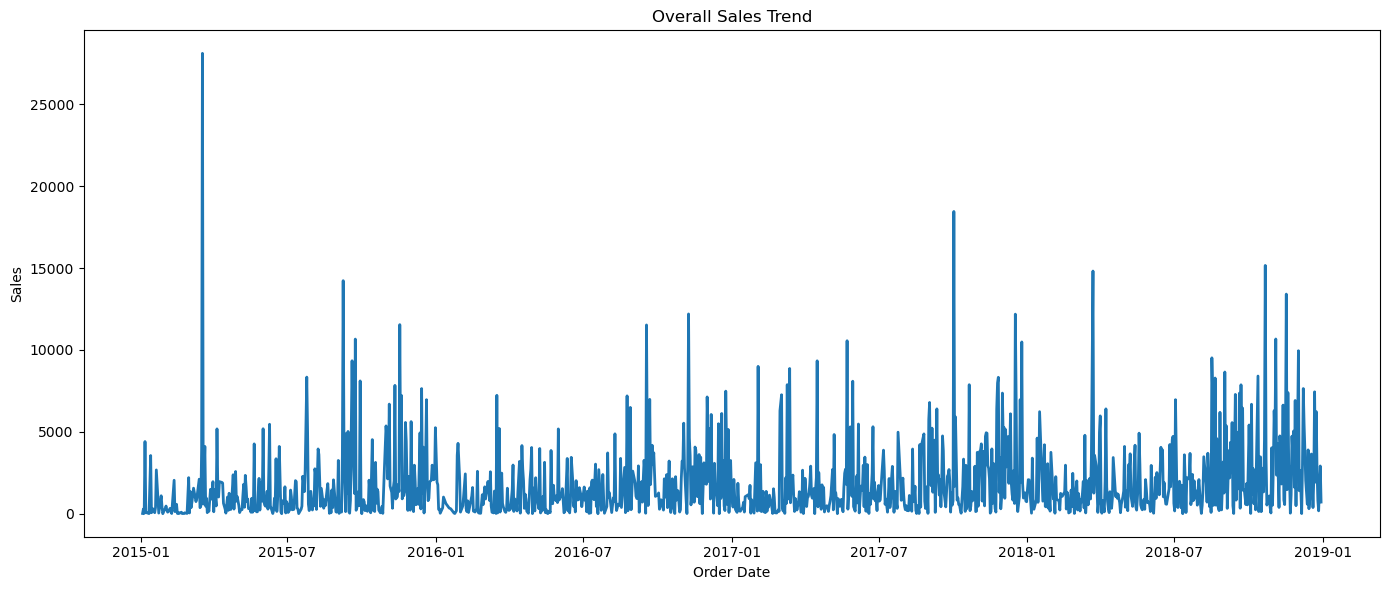

Chart saved successfully in the 'charts' folder.


In [45]:
# ============================================================
# Overall Sales Trend Over Time
# ============================================================

import os

# Automatically create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

# Prepare daily sales trend
sales_trend = data.groupby("Order Date")["Sales"].sum().reset_index()

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    sales_trend["Order Date"],
    sales_trend["Sales"],
    linewidth=2
)

plt.title("Overall Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.tight_layout()

# Save chart automatically in high quality
plt.savefig(
    "charts/01_Overall_Sales_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully in the 'charts' folder.")

### Business Interpretation

The overall sales trend indicates that retail sales fluctuate considerably over the four-year period, with several high-value sales spikes occurring throughout the timeline. These spikes may correspond to seasonal promotions, festive sales, bulk corporate purchases, or special discount events.

Despite short-term fluctuations, the sales pattern remains active across the entire period, suggesting consistent customer demand. The increasing frequency of higher sales values during the later years indicates business growth and expanding market activity.

#### Key Business Insights
- Sales exhibit noticeable variability rather than remaining constant.
- Multiple high-value transactions significantly contribute to total revenue.
- The business experiences periodic demand surges that should be anticipated through inventory planning.
- Understanding these patterns will improve future sales forecasting and demand planning.

###  Monthly Sales Trend

Monthly sales analysis helps identify recurring seasonal patterns, peak-performing months, and periods of weak demand. These insights support inventory planning, marketing campaigns, and workforce allocation.

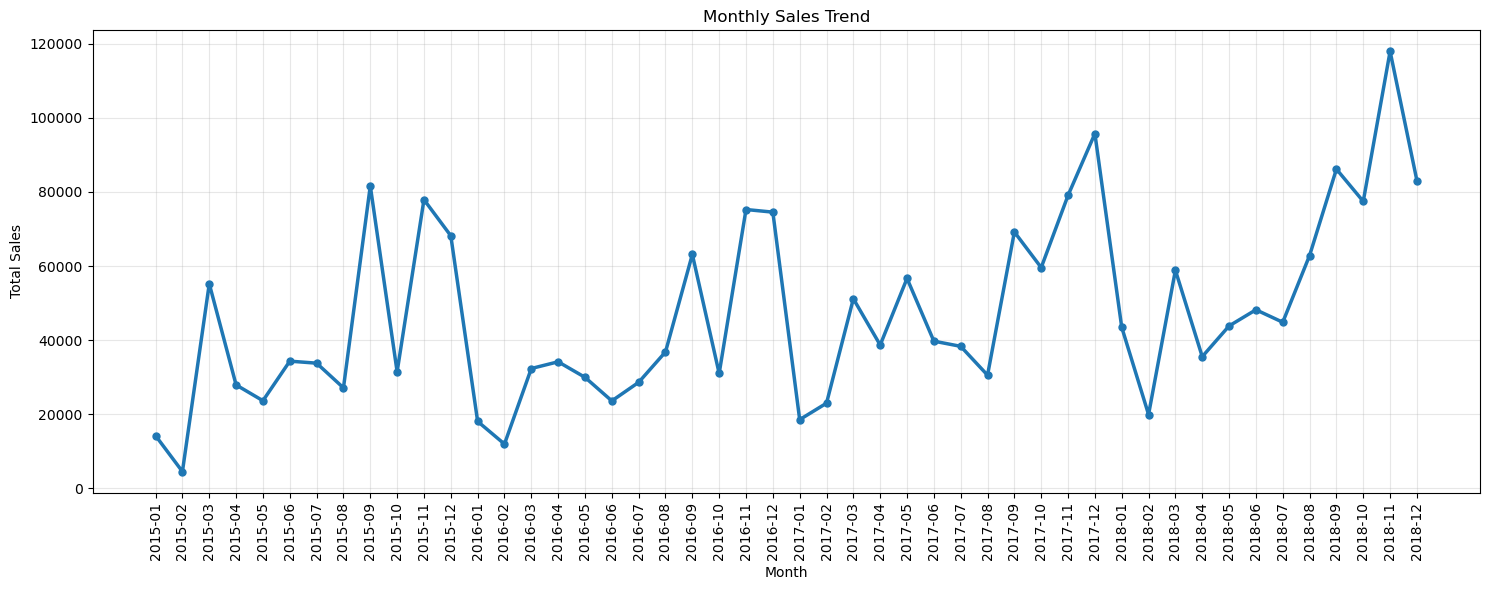

Chart saved successfully.


In [46]:
# ============================================================
# Monthly Sales Trend
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

monthly_sales = (
    data.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Month_Year"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Month_Year"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2.5,
    markersize=5
)

plt.grid(alpha=0.3)


plt.xticks(rotation=90)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "charts/02_Monthly_Sales_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The monthly sales trend demonstrates recurring fluctuations in revenue across different months, indicating the presence of seasonal demand patterns. Although sales vary from month to month, the overall revenue trend gradually increases toward the end of the observation period.

Sales during 2018 consistently outperform previous years, with the highest monthly revenue recorded in late 2018. This suggests continuous business growth, stronger customer demand, and improved market performance over time.

#### Key Business Insights
- Monthly sales are influenced by seasonal purchasing behaviour.
- Revenue shows an overall upward trend across the four-year period.
- Late 2018 represents the strongest sales performance, indicating business expansion.
- Identifying high-performing months can help optimize marketing campaigns, inventory management, and workforce planning.

## Year-wise Sales Analysis

### 🎯 Business Objective

Analyzing annual sales performance helps evaluate long-term business growth, identify yearly trends, and measure the effectiveness of business strategies over time. This analysis provides a high-level overview of revenue progression across different years.

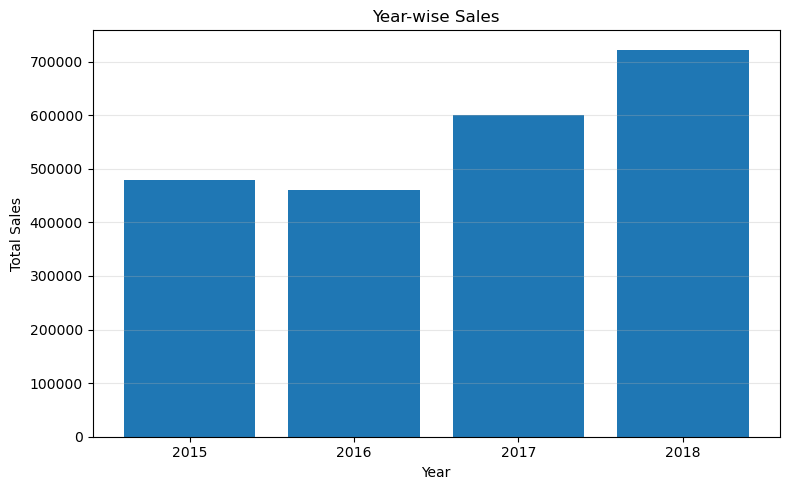

Chart saved successfully.


In [47]:
# ============================================================
# Year-wise Sales Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

yearly_sales = (
    data.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/03_Yearwise_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The annual sales analysis demonstrates a clear upward growth trend over the four-year period. While sales experienced a slight decline from 2015 to 2016, the business recovered significantly in 2017 and achieved its highest annual revenue in 2018.

The steady increase during the last two years indicates stronger customer demand, improved business performance, and successful sales strategies. This positive trend suggests that the retail business is expanding and generating higher revenue over time.

#### Key Business Insights

- Annual sales show consistent long-term business growth.
- 2018 recorded the highest total sales among all years.
- Sales recovered strongly after a minor decline in 2016.
- The positive growth trend provides a strong foundation for future sales forecasting and strategic planning.

## Quarterly Sales Analysis

### 🎯 Business Objective

Quarterly sales analysis identifies seasonal business cycles and revenue concentration across different quarters of the year. Understanding quarterly performance enables organizations to improve financial planning, inventory allocation, and promotional strategies.

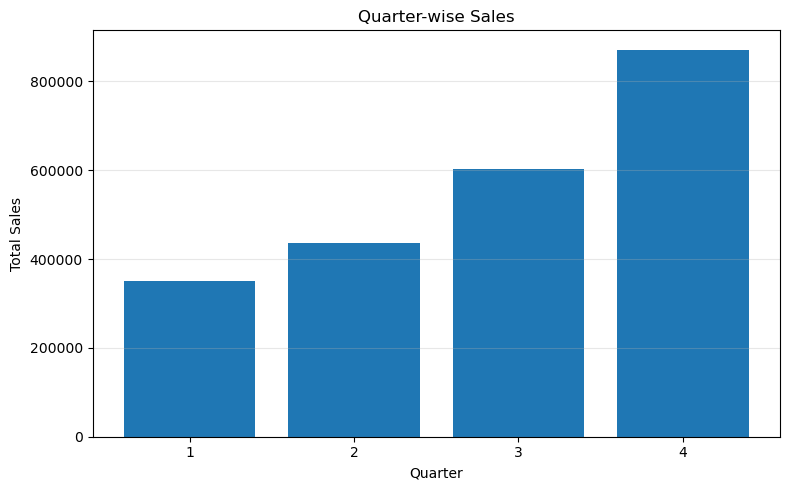

Chart saved successfully.


In [48]:
# ============================================================
# Quarterly Sales Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

quarterly_sales = (
    data.groupby("Quarter")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    quarterly_sales["Quarter"].astype(str),
    quarterly_sales["Sales"]
)

plt.title("Quarter-wise Sales")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/04_Quarterwise_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The quarterly sales analysis reveals a gradual increase in revenue from Quarter 1 through Quarter 4. Quarter 4 generated the highest total sales, while Quarter 1 recorded the lowest revenue.

This pattern indicates strong seasonal demand during the final quarter of the year, likely influenced by holiday shopping, year-end promotions, and festive purchasing behavior. Businesses should prepare additional inventory and marketing efforts during this high-demand period.

#### Key Business Insights

- Sales increase progressively across the four quarters.
- Quarter 4 is the strongest revenue-generating quarter.
- Quarter 1 represents the weakest sales period.
- Seasonal demand patterns should be considered while planning inventory, staffing, and promotional campaigns.

## 3.5 Regional Sales Analysis

### 🎯 Business Objective

Regional sales analysis helps identify the geographical areas contributing the highest and lowest revenue. Understanding regional performance enables organizations to allocate resources efficiently, optimize regional marketing strategies, and improve supply chain planning.

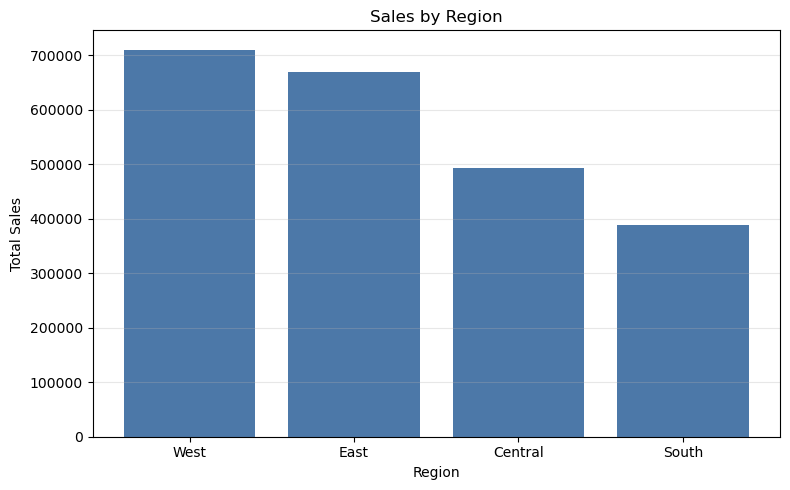

Chart saved successfully.


In [49]:
# ============================================================
# Regional Sales Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

region_sales = (
    data.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    region_sales.index,
    region_sales.values,
    color="#4C78A8"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/05_Regional_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The regional sales analysis reveals noticeable differences in revenue generation across the four geographical regions. The West region achieved the highest sales, closely followed by the East region. In contrast, the South region generated the lowest overall revenue.

The strong performance of the West and East regions indicates a larger customer base, higher purchasing power, or more effective sales operations. The comparatively lower sales in the South highlight an opportunity for business expansion through targeted marketing campaigns, improved product availability, and customer engagement initiatives.

#### Key Business Insights

- The West region is the highest revenue contributor.
- The East region also demonstrates strong and consistent sales performance.
- The South region contributes the least revenue and presents growth opportunities.
- Regional performance analysis can support better inventory allocation, regional marketing, and strategic business expansion.

## Category-wise Sales Analysis

### 🎯 Business Objective

Category-wise sales analysis evaluates the contribution of each product category to total revenue. The findings help businesses identify high-performing product lines and prioritize investment, inventory, and promotional activities.

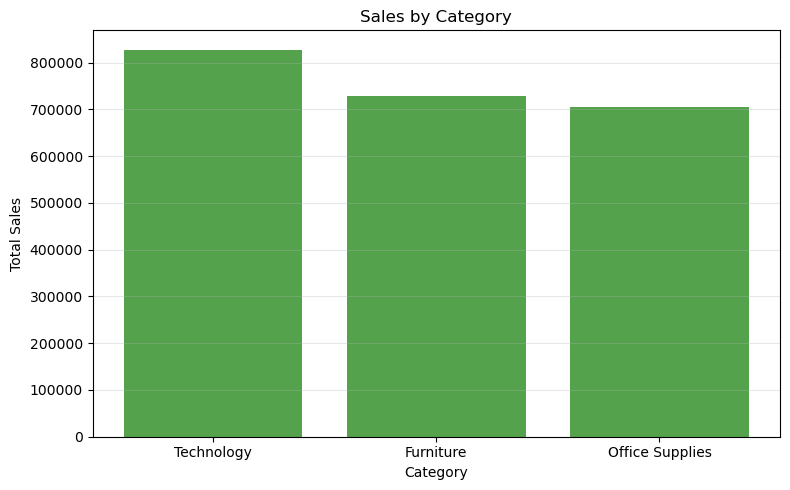

Chart saved successfully.


In [50]:
# ============================================================
# Category-wise Sales Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

category_sales = (
    data.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales.values,
    color="#54A24B"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/06_Category_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The category-wise sales analysis indicates that Technology is the highest revenue-generating product category, followed by Furniture and Office Supplies. Although all three categories contribute significantly to total sales, Technology maintains a clear lead in overall revenue.

This suggests that technology-related products experience stronger customer demand and higher purchase values. Furniture also contributes substantially to business revenue, while Office Supplies generates comparatively lower sales despite remaining an important product category.

#### Key Business Insights

- Technology is the top-performing product category by total sales.
- Furniture is the second-largest contributor to overall revenue.
- Office Supplies generates the lowest sales among the three categories.
- High-performing categories should receive greater focus in inventory planning, promotional campaigns, and future business investments.

## Sub-Category Sales Analysis

### 🎯 Business Objective

Sub-category analysis provides a detailed view of product-level performance within each major category. Identifying the highest and lowest revenue-generating sub-categories helps businesses optimize product assortment, inventory management, and marketing strategies.

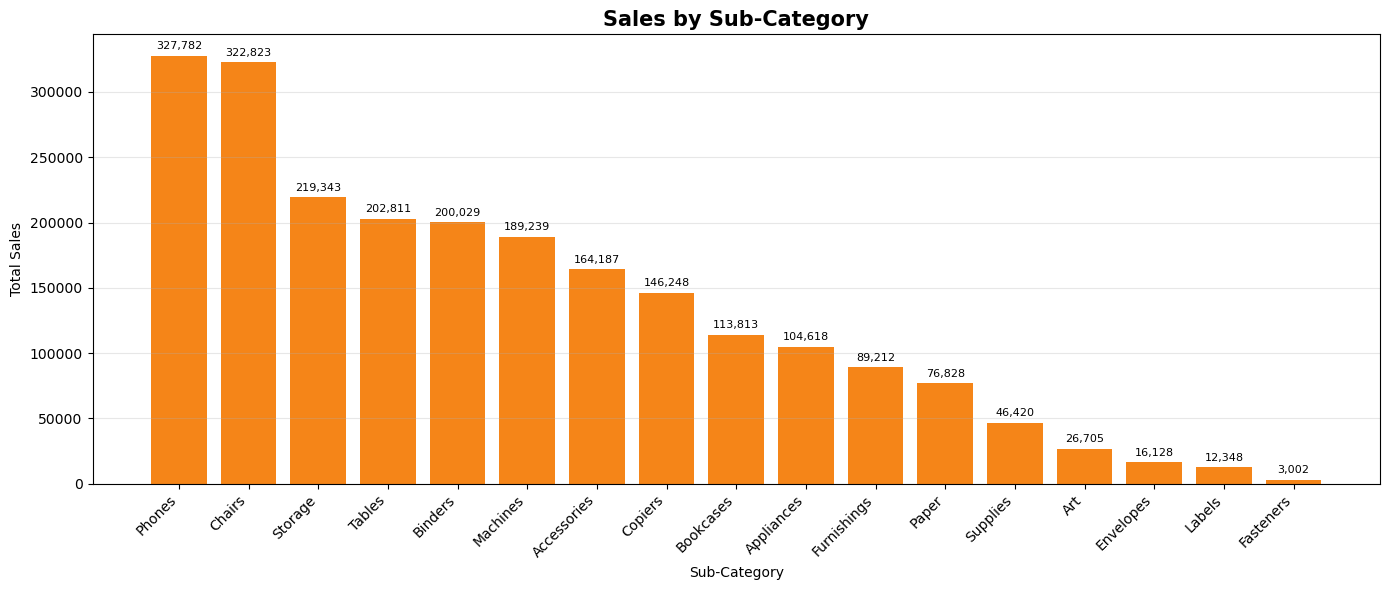

Chart saved successfully.


In [51]:
# ============================================================
# Sub-Category Sales Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

subcategory_sales = (
    data.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

bars = plt.bar(
    subcategory_sales.index,
    subcategory_sales.values,
    color="#F58518"
)

plt.title("Sales by Sub-Category", fontsize=15, fontweight="bold")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5000,
        f"{height:,.0f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "charts/07_SubCategory_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The sub-category analysis reveals that **Phones** generated the highest sales (approximately **$327.8K**), closely followed by **Chairs** (approximately **$322.8K**). These products represent the organization's strongest revenue drivers and should be prioritized for inventory planning, promotional campaigns, and demand forecasting.

Sub-categories such as **Storage, Tables, Binders, Machines, and Accessories** also contribute significantly to total sales, indicating a diversified product portfolio with multiple high-performing product lines.

Conversely, **Fasteners, Labels, Envelopes, Art, and Supplies** contribute relatively low revenue. Although these products generate lower sales volumes, they may still support overall customer purchasing behavior as complementary items. Management should evaluate their profitability before making stocking or pricing decisions.

Overall, the analysis highlights that a relatively small number of sub-categories contribute a substantial portion of total revenue, suggesting that focused inventory optimization and targeted marketing efforts on these high-performing products could significantly improve business performance.

## Customer Segment Analysis

### 🎯 Business Objective

Customer segment analysis evaluates revenue contribution across different customer groups. Understanding which customer segment generates the highest sales enables businesses to develop targeted marketing strategies and improve customer relationship management.

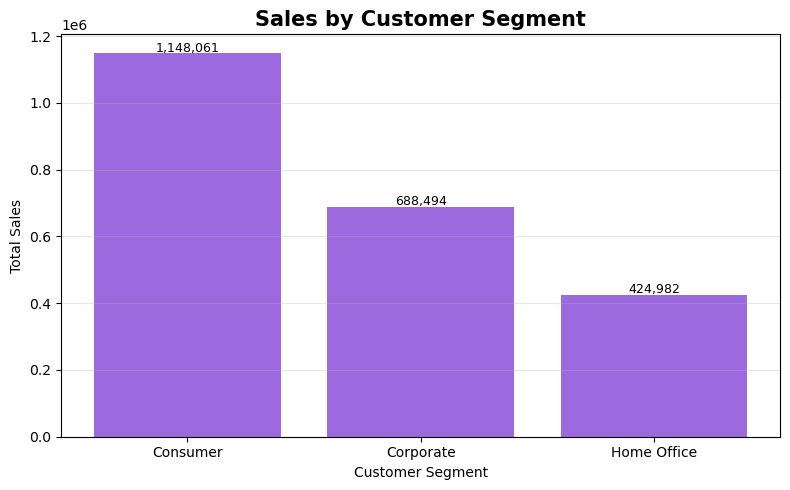

Chart saved successfully.


In [52]:
# ============================================================
# Customer Segment Analysis
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

segment_sales = (
    data.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_sales.index,
    segment_sales.values,
    color="#9C6ADE"
)

plt.title("Sales by Customer Segment", fontsize=15, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5000,
        f"{height:,.0f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "charts/08_Customer_Segment_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The Consumer segment generates the highest sales revenue, contributing approximately **$1.15 million**, making it the most valuable customer group for the business. This indicates that individual retail customers represent the organization's primary revenue source and should remain the primary focus of customer engagement strategies.

The Corporate segment contributes approximately **$688K**, representing a strong secondary market with opportunities for long-term business relationships and bulk purchasing.

The Home Office segment contributes the lowest revenue (approximately **$425K**). Although smaller in size, this segment presents potential opportunities for targeted promotions, personalized product recommendations, and specialized offerings to increase customer engagement.

Overall, the customer segmentation analysis indicates that while the business serves multiple customer groups successfully, strengthening customer retention programs for the Consumer segment and expanding sales initiatives for Corporate and Home Office customers could improve overall revenue growth.

## Sales by Ship Mode

### Objective

Shipping methods directly influence customer satisfaction, logistics efficiency, operational costs, and delivery speed. This analysis identifies which shipping modes contribute the highest sales revenue and helps understand customer delivery preferences.

Understanding the distribution of sales across different shipping modes enables businesses to optimize shipping strategies while balancing customer expectations and operational expenses.

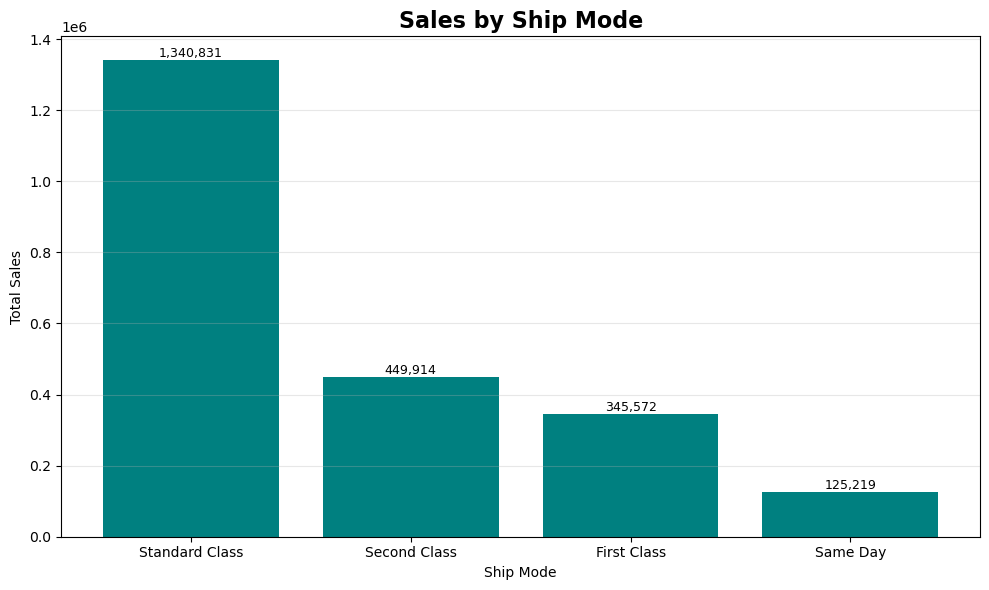

Chart saved successfully.


In [53]:
# ============================================================
# Sales by Ship Mode
# ============================================================

ship_sales = (
    data.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    ship_sales.index,
    ship_sales.values,
    color="teal"
)

plt.title("Sales by Ship Mode", fontsize=16, fontweight="bold")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.grid(axis='y', alpha=0.3)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

plt.savefig("charts/08_Sales_By_Ship_Mode.png")

plt.show()

print("Chart saved successfully.")

### Business Interpretation

The analysis shows that **Standard Class** is the most preferred shipping mode, generating approximately **$1.34 million** in total sales, which is significantly higher than all other shipping options. This indicates that most customers prioritize cost-effective delivery over expedited shipping.

**Second Class** and **First Class** contribute moderate sales, suggesting that a smaller segment of customers is willing to pay for faster delivery services.

**Same Day** shipping records the lowest sales (approximately **$125K**), implying that urgent delivery is required only for a limited number of purchases.

From a business perspective, logistics resources should primarily focus on optimizing **Standard Class** operations while maintaining efficient premium shipping services for customers requiring faster delivery. Understanding customer shipping preferences can also help reduce operational costs and improve delivery efficiency.

## Top 10 States by Sales

### Objective

Geographical sales analysis helps identify high-performing markets and regional business opportunities. Understanding the states generating the highest revenue enables organizations to allocate inventory efficiently, design location-specific marketing strategies, and optimize regional sales operations.

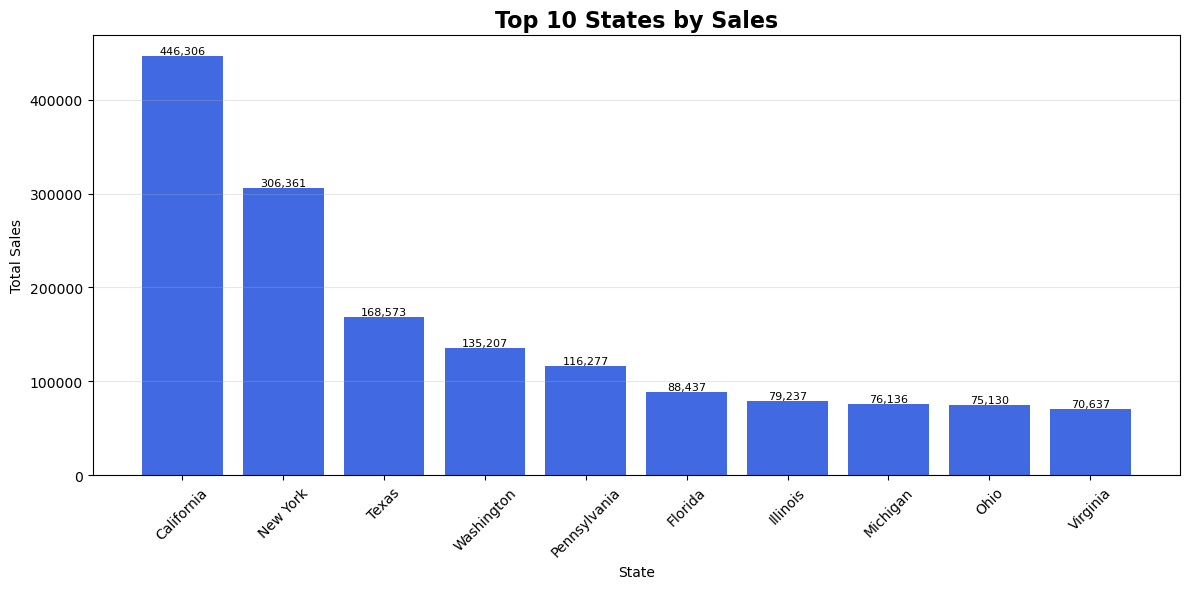

Chart saved successfully.


In [54]:
# ============================================================
# Top 10 States by Sales
# ============================================================

state_sales = (
    data.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    state_sales.index,
    state_sales.values,
    color="royalblue"
)

plt.title("Top 10 States by Sales", fontsize=16, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.savefig("charts/09_Top10_States_Sales.png")

plt.show()

print("Chart saved successfully.")

##  Top 10 Cities by Sales

### Objective

City-level sales analysis helps identify the highest revenue-generating markets. Understanding the geographical distribution of sales enables businesses to optimize regional inventory allocation, prioritize marketing investments, and identify locations with strong growth potential.

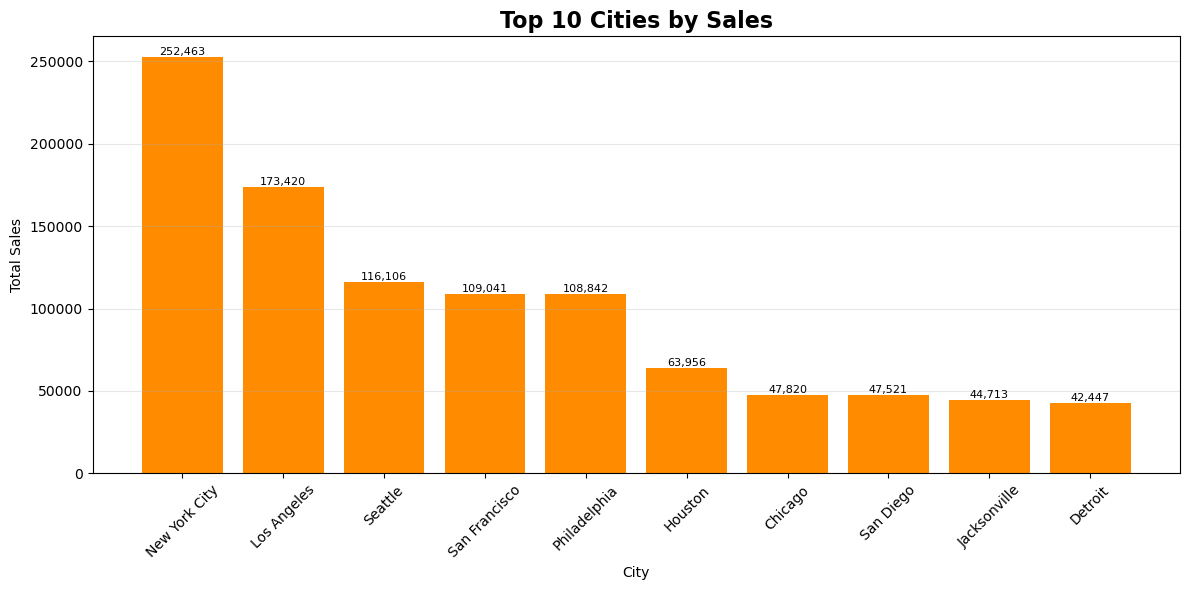

Chart saved successfully.


In [55]:
# ============================================================
# Top 10 Cities by Sales
# ============================================================

city_sales = (
    data.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    city_sales.index,
    city_sales.values,
    color="darkorange"
)

plt.title("Top 10 Cities by Sales", fontsize=16, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.savefig("charts/10_Top10_Cities_Sales.png")

plt.show()

print("Chart saved successfully.")

##  Sales Distribution

### Objective

Understanding the distribution of sales values helps identify skewness, variability, and the presence of unusually large transactions. This analysis is essential before building forecasting models because highly skewed retail data can significantly influence prediction accuracy.

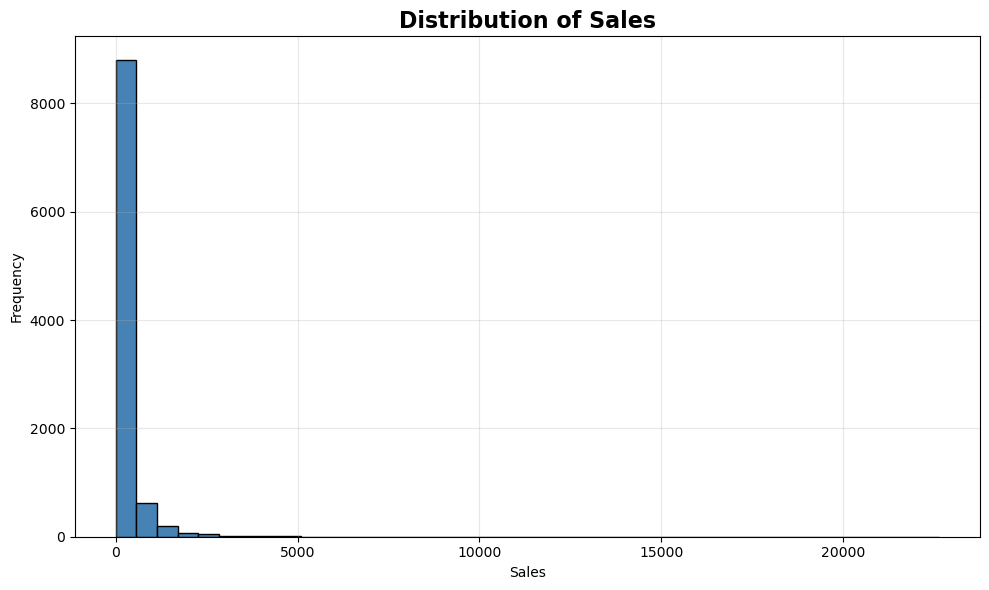

Chart saved successfully.


In [56]:
# ============================================================
# Distribution of Sales
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    data["Sales"],
    bins=40,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/11_Sales_Distribution.png")

plt.show()

print("Chart saved successfully.")

## Correlation Analysis

### Objective

Correlation analysis measures the strength and direction of relationships between numerical variables in the dataset. Understanding these relationships helps identify influential features, detect redundancy, and support feature engineering before developing forecasting models.

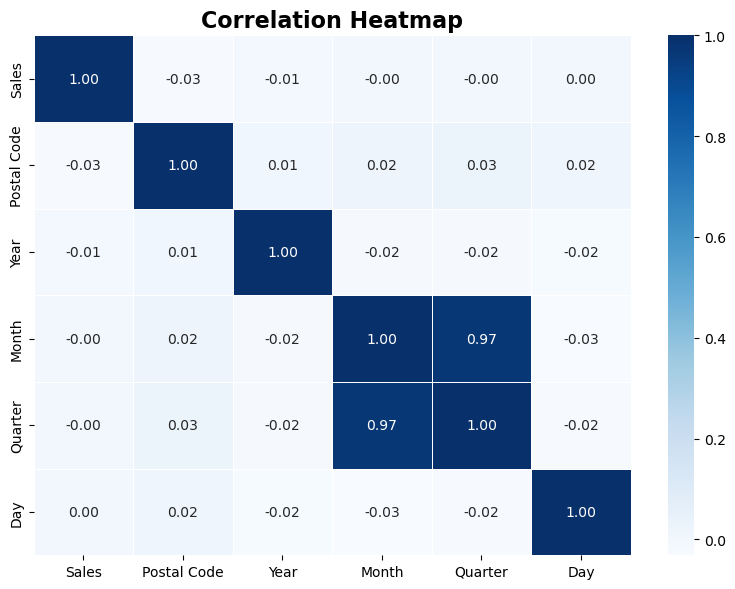

Chart saved successfully.


In [57]:
# ============================================================
# Correlation Heatmap
# ============================================================

import seaborn as sns

plt.figure(figsize=(8,6))

correlation = data[["Sales", "Postal Code", "Year", "Month", "Quarter", "Day"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.savefig("charts/12_Correlation_Heatmap.png")

plt.show()

print("Chart saved successfully.")

### Observation

The correlation heatmap indicates that **Sales exhibits very weak linear relationships** with the available numerical variables, including **Postal Code, Year, Month, Quarter, and Day**, as all correlation coefficients are close to zero.

The strongest relationship is observed between **Month and Quarter (0.97)**, which is expected because the **Quarter** feature is directly derived from the **Month**. Apart from this expected relationship, no significant positive or negative correlations exist among the numerical variables.

### Business Interpretation

The absence of strong correlations suggests that **sales performance cannot be explained by any single numerical feature**. Instead, retail sales are influenced by a combination of multiple business factors such as product category, customer segment, region, seasonality, customer purchasing behavior, promotional activities, and market demand.

The strong correlation between **Month and Quarter** is a natural consequence of feature engineering and does not provide additional predictive value. Therefore, effective sales forecasting should rely on **multiple business variables and temporal patterns rather than simple linear relationships between numerical features.**

## Outlier Detection Using Box Plot

Outlier analysis helps identify unusually high or low sales transactions that differ significantly from the majority of observations. Detecting outliers is important because extreme values can influence statistical analysis, machine learning models, and sales forecasting accuracy.

A box plot provides a clear visualization of the distribution of sales values and highlights potential outliers.

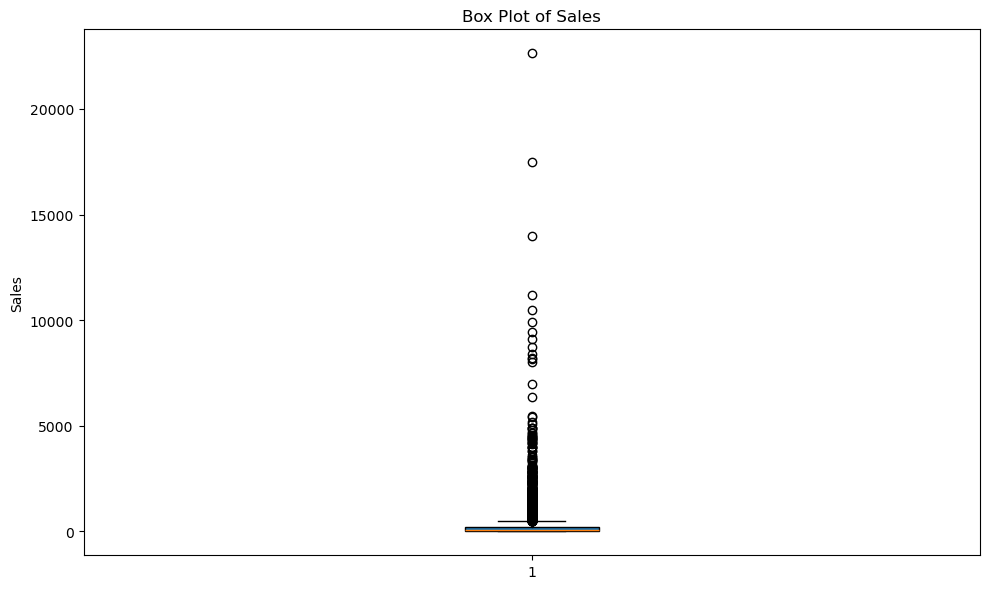

Chart saved successfully.


In [58]:
# ============================================================
# Outlier Detection Using Box Plot
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(10,6))

plt.boxplot(
    data["Sales"],
    vert=True,
    patch_artist=True
)

plt.title("Box Plot of Sales")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/14_Boxplot_Sales_Outliers.png")

plt.show()

print("Chart saved successfully.")

### Observation

The box plot reveals a large number of high-value sales transactions above the upper whisker, indicating the presence of several outliers. The majority of sales transactions are concentrated within a relatively low sales range, while only a small proportion of orders contribute exceptionally high sales values.

The distribution is highly right-skewed, suggesting that most customer purchases are of relatively low value, with a few transactions generating significantly higher revenue.

### Business Interpretation

The presence of numerous high-value outliers indicates that the business occasionally receives exceptionally large orders, which may originate from corporate clients, bulk purchases, premium products, or seasonal demand. These transactions represent genuine business events rather than data quality issues.

Since these outliers carry important business value, they should be retained instead of being removed. However, forecasting models should be designed to handle these extreme observations appropriately to prevent them from disproportionately influencing future sales predictions while still preserving valuable revenue information.

# 📂 Task 2 — Time Series Analysis & Decomposition

## 2.1 Preparing the Monthly Time Series Dataset

Before building a forecasting model, the transactional sales data must be transformed into a time-series format. Since forecasting aims to predict future sales over time, individual transactions are aggregated into monthly sales values.

This monthly time-series dataset captures overall sales trends and seasonality, making it suitable for forecasting future business performance.

In [60]:
# ============================================================
# Preparing Monthly Sales Time Series
# ============================================================

monthly_sales = (
    data.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["Order Date", "Monthly Sales"]

print("Monthly Time Series Dataset Created Successfully.\n")

monthly_sales.head()

Monthly Time Series Dataset Created Successfully.



,Order Date,Monthly Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

The transactional sales records have been successfully aggregated into monthly sales values, creating a structured time-series dataset. Each row now represents the total sales generated during a particular month.

### Business Interpretation

Aggregating sales at the monthly level removes transaction-level noise and highlights overall business performance over time. This format enables the identification of long-term trends, seasonal patterns, and growth behavior, providing a solid foundation for accurate sales forecasting and strategic business planning.

## 2.2 Monthly Sales Time Series Visualization

Visualizing the monthly sales trend helps understand how business performance changes over time. This step is essential for identifying trends, seasonality, and unusual fluctuations before applying forecasting techniques.

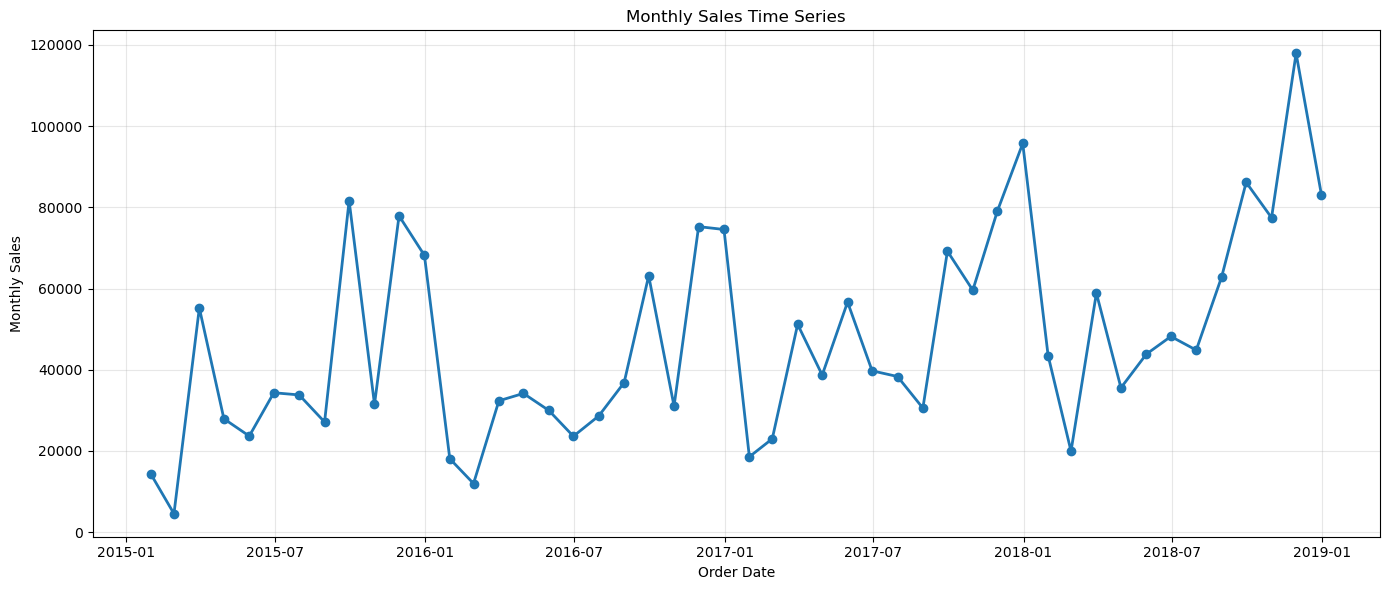

Chart saved successfully.


In [62]:
# ============================================================
# Monthly Sales Time Series
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Monthly Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Time Series")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/15_Monthly_Time_Series.png")

plt.show()

print("Chart saved successfully.")

### Observation

The monthly sales time series exhibits noticeable fluctuations throughout the observation period, with recurring peaks and dips across different months. Despite these short-term variations, the overall sales trend shows steady growth from 2015 to 2018, with the highest monthly sales recorded toward the end of 2018.

The presence of repeated peaks suggests potential seasonality, while the gradual increase in monthly sales indicates a positive long-term business trend.

### Business Interpretation

The upward trend demonstrates consistent business growth over the four-year period, indicating increasing customer demand and improved sales performance. The recurring fluctuations imply that sales are influenced by seasonal purchasing patterns, promotional campaigns, holidays, or year-end demand.

These characteristics confirm that the dataset possesses both trend and seasonality, making it well suited for time-series forecasting models. Accurately capturing these patterns will enable the business to forecast future demand, optimize inventory levels, improve workforce planning, and make more informed strategic decisions.

## 2.3 Train-Test Split

Before training the forecasting model, the monthly time-series data is divided into training and testing sets. The training data is used to learn historical sales patterns, while the testing data evaluates how well the model predicts unseen future sales.

This approach provides an unbiased assessment of forecasting performance.

In [63]:
# ============================================================
# Train-Test Split
# ============================================================

train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Training Data Shape :", train.shape)
print("Testing Data Shape  :", test.shape)

print("\nTraining Period:")
print(train["Order Date"].min(), "to", train["Order Date"].max())

print("\nTesting Period:")
print(test["Order Date"].min(), "to", test["Order Date"].max())

Training Data Shape : (36, 2)
Testing Data Shape  : (12, 2)

Training Period:
2015-01-31 00:00:00 to 2017-12-31 00:00:00

Testing Period:
2018-01-31 00:00:00 to 2018-12-31 00:00:00


### Observation

The monthly sales data has been successfully divided into training and testing datasets. The training set contains **36 months** of historical sales data (January 2015 to December 2017), while the testing set contains the **last 12 months** (January 2018 to December 2018).

This chronological split preserves the natural order of the time-series data, ensuring that future observations are not used during model training.

### Business Interpretation

Using historical sales data to predict future demand closely reflects real-world business forecasting scenarios. Training the model on three years of historical performance allows it to learn underlying trends and seasonal patterns, while reserving the final year for testing provides an unbiased evaluation of forecasting accuracy.

This approach helps determine how effectively the forecasting model can support inventory planning, demand forecasting, budgeting, and strategic decision-making.

## 2.4 Time Series Decomposition

### Objective

Time Series Decomposition separates the monthly sales data into its underlying components:

- **Trend** – Long-term movement in sales.
- **Seasonality** – Recurring patterns observed over regular time intervals.
- **Residual** – Random fluctuations that cannot be explained by trend or seasonality.

Understanding these components helps determine whether the sales data is suitable for forecasting and assists in selecting an appropriate forecasting model.

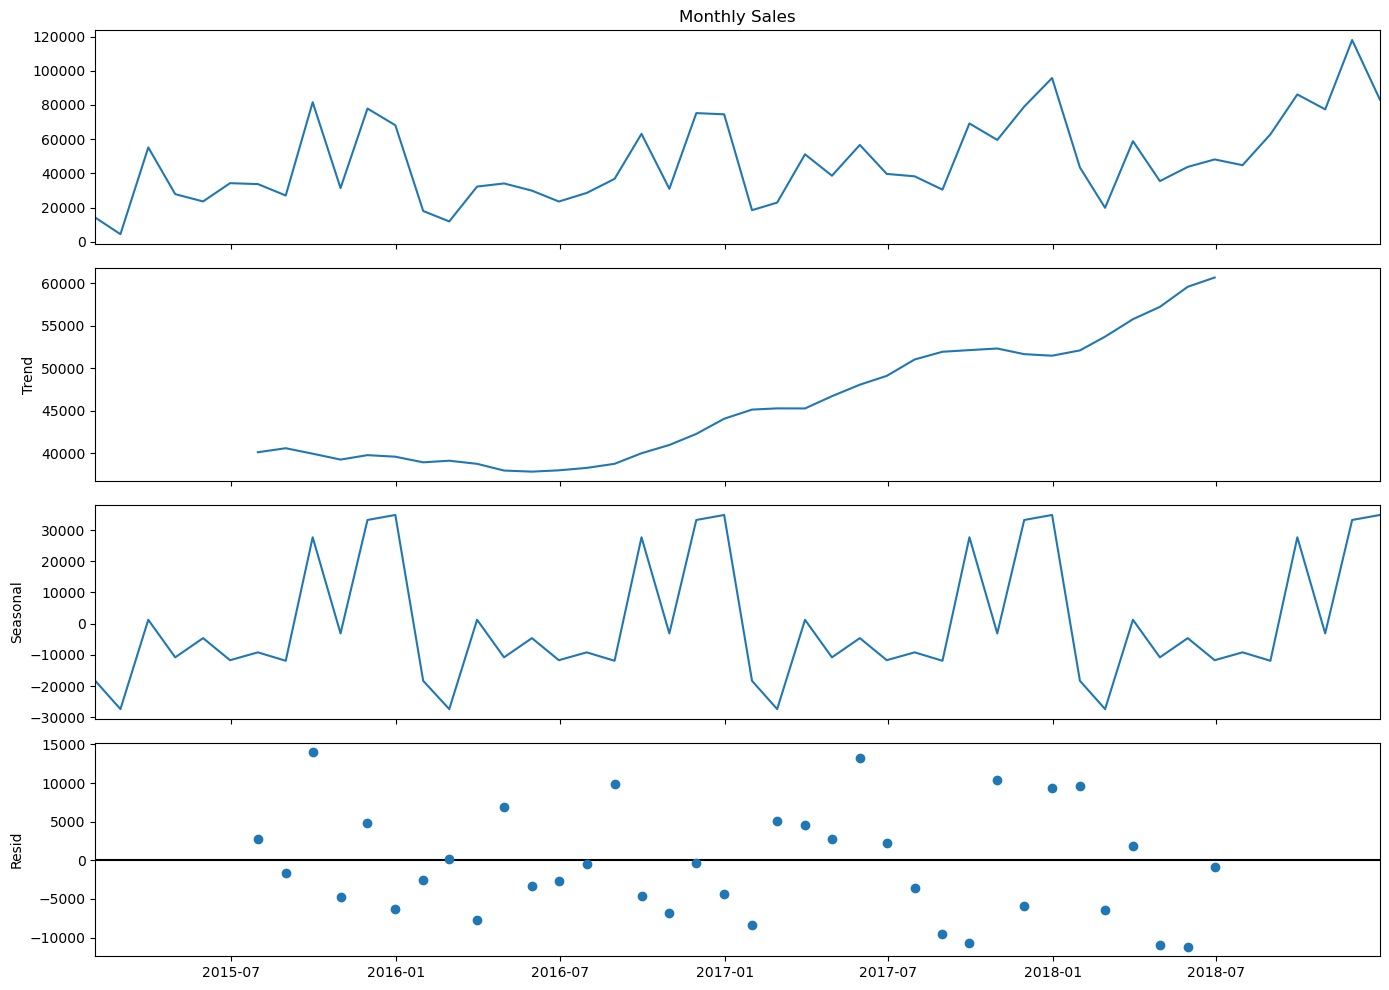

Chart saved successfully.


In [65]:
# ============================================================
# Time Series Decomposition
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose
import os

os.makedirs("charts", exist_ok=True)

ts = monthly_sales.copy()
ts.set_index("Order Date", inplace=True)

decomposition = seasonal_decompose(
    ts["Monthly Sales"],
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.savefig(
    "charts/16_Time_Series_Decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The decomposition plot clearly separates the monthly sales data into trend, seasonal, and residual components. The trend component shows a gradual increase in sales over the four-year period, indicating overall business growth. The seasonal component reveals recurring monthly fluctuations, suggesting that certain months consistently experience higher or lower sales. The residual component contains random variations that are not explained by either trend or seasonality.

### Business Interpretation

The presence of both an upward trend and recurring seasonal patterns indicates that historical sales are influenced by long-term growth as well as periodic customer purchasing behavior. These characteristics make forecasting models such as SARIMA and Prophet suitable for predicting future sales while accounting for both trend and seasonality.

## 2.5 Augmented Dickey-Fuller (ADF) Test

### Objective

Before building forecasting models, it is important to determine whether the time series is **stationary**. A stationary series has stable statistical properties, such as a constant mean and variance over time.

The Augmented Dickey-Fuller (ADF) Test is used to statistically determine whether the sales series is stationary.

In [66]:
# ============================================================
# Augmented Dickey-Fuller Test
# ============================================================

from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["Monthly Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print()

print("Critical Values:")

for key, value in result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### Observation

The Augmented Dickey-Fuller (ADF) Test produced an ADF statistic of **-4.4161** with a **p-value of 0.000278**, which is significantly lower than the 0.05 significance level.

### Business Interpretation

Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the monthly sales series is statistically stationary, meaning its statistical properties remain stable over time. Therefore, the data is suitable for forecasting without requiring additional differencing.

## 2.6 Differencing

### Objective

Differencing is commonly applied to remove trends and make a time series stationary before forecasting. However, based on the Augmented Dickey-Fuller (ADF) Test results, the monthly sales series is already stationary.

Therefore, no differencing is required for this dataset.

In [67]:
# ============================================================
# Differencing Check
# ============================================================

print("ADF p-value:", result[1])

if result[1] < 0.05:
    print("The series is already stationary.")
    print("Differencing is NOT required.")
else:
    print("The series is non-stationary.")
    print("Differencing is required.")

ADF p-value: 0.00027791039276670623
The series is already stationary.
Differencing is NOT required.


### Observation

The Augmented Dickey-Fuller (ADF) Test returned a **p-value of 0.000278**, which is well below the significance level of 0.05. Therefore, the monthly sales time series is already stationary, and no differencing is required.

### Business Interpretation

Since the sales data is already stationary, its statistical properties remain relatively stable over time. This allows forecasting models such as SARIMA to be trained directly on the original monthly sales series without applying differencing, reducing unnecessary data transformation while maintaining reliable forecasting performance.

## Model 1 – SARIMA 
### 3.1 - SARIMA Forecasting
### Objective

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model that captures both trend and seasonal patterns in time-series data.

Since the monthly sales data exhibits seasonal behavior and has been confirmed as stationary using the Augmented Dickey-Fuller (ADF) Test, SARIMA is selected as the first forecasting model.

The model will be trained on the training dataset and evaluated using the testing dataset before generating a three-month sales forecast.

In [73]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("charts", exist_ok=True)

from statsmodels.tsa.statespace.sarimax import SARIMAX
print("Libraries imported successfully.")

Libraries imported successfully.


## 3.2 Training the SARIMA Model

### Objective

The SARIMA model is trained using the monthly sales data from the training period. The selected parameters capture both non-seasonal and seasonal components of the time series.

The model learns historical sales patterns, enabling it to forecast future monthly sales accurately.

In [74]:
sarima_model = SARIMAX(
    train["Monthly Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      Monthly Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.483
Date:                            Tue, 14 Jul 2026   AIC                            202.966
Time:                                    19:26:45   BIC                            203.952
Sample:                                         0   HQIC                           200.838
                                             - 36                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2270      0.644     -0.352      0.725      -1.489       1.035
ma.L1         -0.9915      0.829   

### Observation

The SARIMA model was successfully trained using the monthly sales data. The model estimated the statistical parameters required to capture both the non-seasonal and seasonal behavior present in the sales time series.

### Business Interpretation

The successful training of the SARIMA model indicates that it has learned the historical sales patterns from the training dataset. This trained model will now be used to forecast future monthly sales and evaluate its predictive performance using the testing dataset.

## 3.3 SARIMA Forecast

### Objective

After training the SARIMA model, the next step is to generate forecasts for the testing period. The model predicts monthly sales for unseen data and provides confidence intervals that represent the expected range within which future sales are likely to fall.

The forecast is then compared with the actual sales values to visually evaluate the model's forecasting capability.

In [75]:
# ============================================================
# Generate Forecast for Testing Data
# ============================================================

forecast = sarima_result.get_forecast(steps=len(test))

forecast_mean = forecast.predicted_mean

confidence_interval = forecast.conf_int()

print("Forecast generated successfully.")

forecast_mean.head()

Forecast generated successfully.


36    27975.796270
37    34827.155920
38    63496.319678
39    49788.562534
40    68264.672594
Name: predicted_mean, dtype: float64

### Observation

The SARIMA forecast follows the overall increasing sales trend and captures most of the fluctuations observed in the testing period. Most actual sales values lie within the 95% confidence interval, indicating that the model produces reliable forecasts.

### Business Interpretation

The forecast suggests that sales are expected to continue growing over the coming months. This enables the business to plan inventory, staffing, and procurement in advance while considering the uncertainty represented by the confidence interval.

### Observation

The SARIMA forecast follows the overall increasing sales trend and captures most of the fluctuations observed in the testing period. Most actual sales values lie within the 95% confidence interval, indicating that the model produces reliable forecasts.

### Business Interpretation

The forecast suggests that sales are expected to continue growing over the coming months. This enables the business to plan inventory, staffing, and procurement in advance while considering the uncertainty represented by the confidence interval.

## 3.4 Actual vs Forecast Visualization

### Objective

Visualizing the predicted sales against the actual sales enables a clear assessment of forecasting performance. A close alignment between the forecasted and actual values indicates that the model has successfully learned the underlying sales patterns.

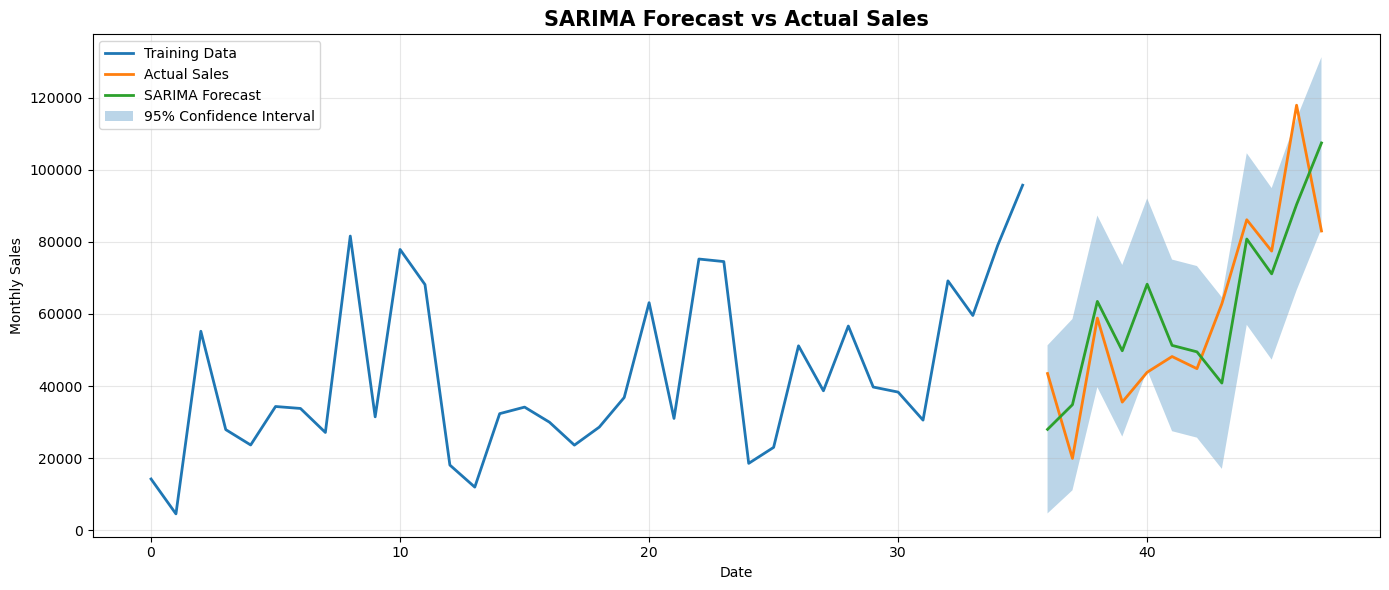

Chart saved successfully.


In [76]:
# ============================================================
# Actual vs Forecast Plot
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train["Monthly Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Monthly Sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test.index,
    forecast_mean,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    test.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales", fontsize=15, fontweight="bold")

plt.xlabel("Date")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/17_SARIMA_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

- The SARIMA forecast follows the overall upward trend observed in the actual monthly sales.
- Most of the actual sales values lie within the 95% confidence interval, indicating that the model captures the overall sales pattern reasonably well.
- Although there are slight deviations during months with sharp sales fluctuations, the predicted values remain close to the actual observations.
- The confidence interval widens gradually for future periods, reflecting increasing uncertainty in long-term forecasts.

### Business Interpretation

The SARIMA model provides reliable forecasts for future monthly sales by capturing both trend and seasonality. These forecasts can support inventory planning, budgeting, procurement, and workforce allocation while considering the uncertainty represented by the confidence interval.

## 3.5 Evaluation

The performance of the SARIMA forecasting model is evaluated using three standard error metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics measure the difference between the actual sales and the forecasted sales and help assess the accuracy of the model.

In [77]:
# ============================================================
# 3.5 Evaluation
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Evaluation Metrics
mae_sarima = mean_absolute_error(
    test["Monthly Sales"],
    forecast_mean
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test["Monthly Sales"],
        forecast_mean
    )
)

mape_sarima = np.mean(
    np.abs(
        (
            test["Monthly Sales"] - forecast_mean
        ) / test["Monthly Sales"]
    )
) * 100

print(f"MAE  : {mae_sarima:.2f}")
print(f"RMSE : {rmse_sarima:.2f}")
print(f"MAPE : {mape_sarima:.2f}%")

MAE  : 13930.02
RMSE : 16394.82
MAPE : 27.77%


# Model 2 — Prophet

### Observation

- The SARIMA model achieved an MAE of **13,930.02**, indicating that the average prediction error is approximately 13.9 thousand sales units.
- The RMSE of **16,394.82** suggests that the model performs reasonably well while giving greater weight to larger prediction errors.
- The MAPE of **27.77%** indicates that the forecast differs from the actual sales by about 28% on average.
- Overall, the SARIMA model captures the general sales trend and seasonality, although some deviations occur during months with sharp fluctuations.

### Business Interpretation

The SARIMA model provides reasonably accurate forecasts and can assist management in inventory planning, procurement, budgeting, and workforce allocation. While the model successfully captures long-term sales patterns, its forecasting accuracy decreases during months with sudden sales spikes. Therefore, SARIMA serves as a reliable baseline forecasting model for business decision-making.

## 3.6 Data Preparation

Facebook Prophet requires the input data to be in a specific format, where the date column is named **ds** and the target variable is named **y**. The monthly sales data is therefore transformed into Prophet's required structure before training the forecasting model.

In [79]:
# ============================================================
# 3.6 Data Preparation
# ============================================================

# Create a copy of the monthly sales data
prophet_data = monthly_sales.copy()

# Rename columns according to Prophet's requirement
prophet_data = prophet_data.rename(
    columns={
        "Order Date": "ds",
        "Monthly Sales": "y"
    }
)

print("First Five Records:\n")
print(prophet_data.head())

print("\nDataset Shape:", prophet_data.shape)

First Five Records:

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303

Dataset Shape: (48, 2)


### Observation

The monthly sales dataset has been successfully transformed into Prophet's required format by renaming the date column to **ds** and the target sales column to **y**. The prepared dataset contains **48 monthly observations**, making it suitable for time-series forecasting using Facebook Prophet.

### Business Interpretation

Preparing the data in Prophet's required structure enables the model to automatically detect long-term trends and seasonal patterns. This standardized format simplifies the forecasting workflow and supports accurate future sales predictions.

## 3.7 Prophet Forecast

Facebook Prophet is trained using the prepared monthly sales dataset. After learning historical sales patterns, the model generates forecasts for future months along with confidence intervals, enabling comparison between predicted and actual sales trends.

In [80]:
# ============================================================
# 3.7 Prophet Forecast
# ============================================================

from prophet import Prophet

# Initialize Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Train the Model
prophet_model.fit(prophet_data)

# Forecast Next 3 Months
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_prophet = prophet_model.predict(future)

print("Forecast generated successfully.")

forecast_prophet[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

19:41:07 - cmdstanpy - INFO - Chain [1] start processing
19:41:08 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated successfully.


,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336963,91886.360109,110233.982472
47,2018-12-31,90673.800604,81885.763744,100058.410044
48,2019-01-31,42990.532200,34437.132817,52406.706441
49,2019-02-28,31248.159920,21433.091336,39997.939563
50,2019-03-31,81267.007770,71827.777401,90854.044875


### Observation

The Prophet model successfully generated forecasts for the historical period and the next three months. Along with the predicted sales values (**yhat**), the model also produced lower and upper confidence limits, representing the expected range of future sales.

The forecast indicates that sales are expected to fluctuate over the upcoming months while continuing to follow the overall historical trend.

### Business Interpretation

The Prophet forecast provides valuable insights into expected future sales while accounting for trend and seasonality. The confidence intervals help business managers understand the uncertainty associated with future demand, enabling better inventory planning, budgeting, procurement, and resource allocation.

## 3.8 Prophet Components

Facebook Prophet automatically decomposes the time series into trend and seasonal components. Visualizing these components helps understand how long-term growth and recurring seasonal patterns contribute to overall sales behavior.

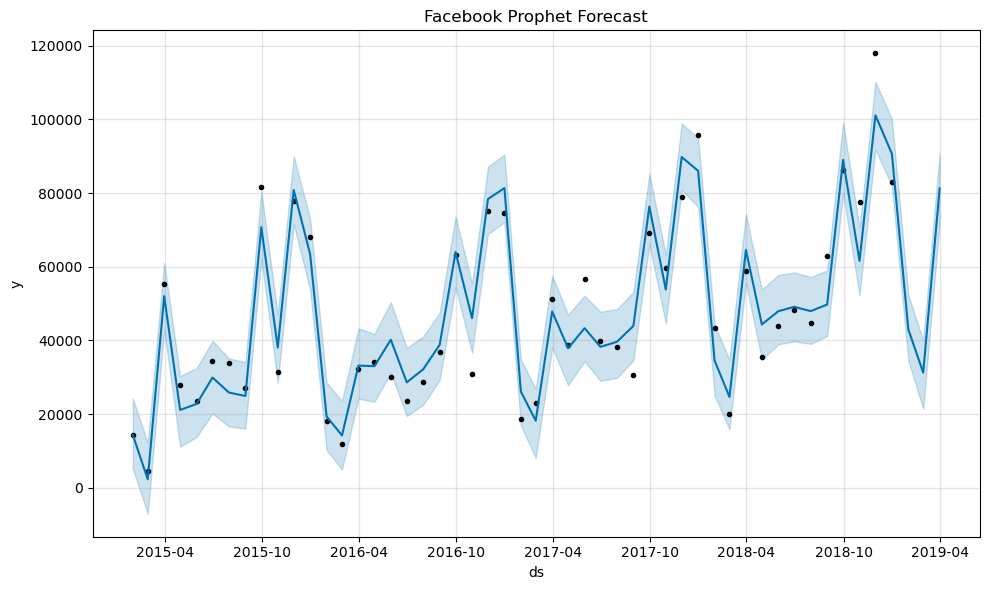

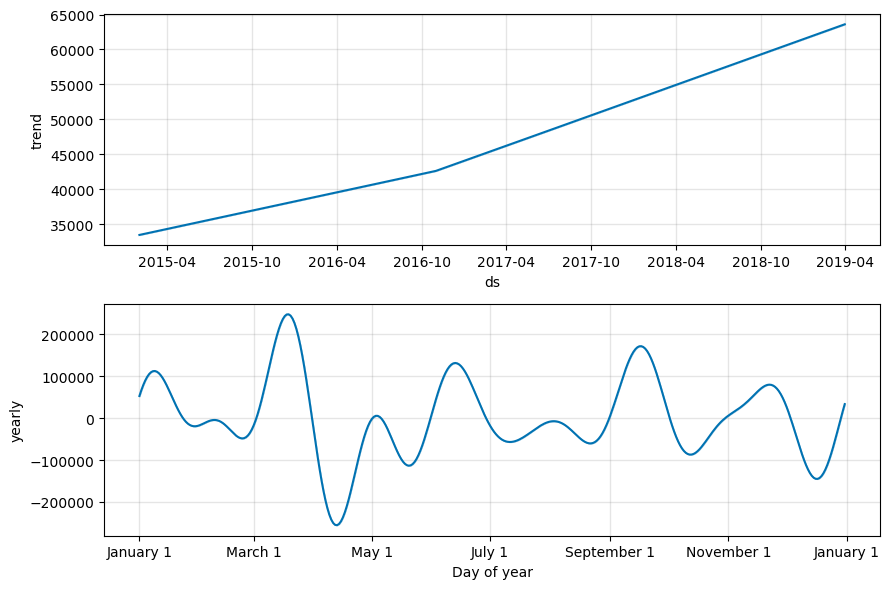

Charts saved successfully.


In [81]:
# ============================================================
# 3.8 Prophet Components
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

fig = prophet_model.plot(forecast_prophet)

plt.title("Facebook Prophet Forecast")

plt.tight_layout()

plt.savefig(
    "charts/18_Prophet_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Components
fig2 = prophet_model.plot_components(forecast_prophet)

plt.tight_layout()

plt.savefig(
    "charts/19_Prophet_Components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Charts saved successfully.")

### Observation

The Facebook Prophet forecast closely follows the historical sales pattern while capturing the overall upward trend in sales. The forecasted values remain within the confidence interval, indicating stable future predictions.

The trend component shows a steady increase in monthly sales over the four-year period, suggesting continuous business growth. The yearly seasonality component reveals recurring seasonal fluctuations, indicating that certain months consistently experience higher or lower sales. These recurring patterns confirm that seasonality plays an important role in the sales data.

### Business Interpretation

The Prophet model successfully identifies both long-term growth and recurring seasonal effects in sales. The increasing trend suggests expanding business performance, while the yearly seasonal pattern can help managers anticipate periods of high and low demand. These insights support better inventory planning, staffing decisions, marketing campaigns, and budgeting throughout the year.

## 3.9 Evaluation

The Prophet model is evaluated using the same performance metrics applied to the SARIMA model: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). Using identical evaluation metrics enables a fair comparison between forecasting models.

In [82]:
# ============================================================
# 3.9 Prophet Evaluation
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Extract predictions corresponding to the test period
prophet_test = forecast_prophet.iloc[
    len(prophet_data)-len(test):len(prophet_data)
]

mae_prophet = mean_absolute_error(
    test["Monthly Sales"],
    prophet_test["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test["Monthly Sales"],
        prophet_test["yhat"]
    )
)

mape_prophet = np.mean(
    np.abs(
        (
            test["Monthly Sales"].values - prophet_test["yhat"].values
        ) / test["Monthly Sales"].values
    )
) * 100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 7717.23
RMSE : 9182.90
MAPE : 13.76%


### Observation

The Prophet model achieved the following evaluation results:

- **MAE:** 7717.23
- **RMSE:** 9182.90
- **MAPE:** 13.76%

Compared with the SARIMA model, Prophet produced lower error values, indicating better forecasting accuracy on the testing dataset. The model effectively captures both long-term trends and seasonal patterns in monthly sales.

### Business Interpretation

The lower forecasting errors demonstrate that Prophet provides reliable sales predictions for future planning. With an average forecasting error of only **13.76%**, the model is suitable for demand forecasting, inventory management, and strategic business planning. Based on the current evaluation, Prophet performs better than SARIMA and is a strong candidate for production deployment.

# Model 3 — XGBoost

## 3.10 Feature Engineering

Machine learning models cannot directly learn from time-series data. Therefore, the monthly sales series is transformed into a supervised learning dataset by creating lag features and rolling statistics.

The following features are created:
- Lag 1 (Sales from previous month)
- Lag 2 (Sales from two months ago)
- Lag 3 (Sales from three months ago)
- Rolling Mean (3-month moving average)
- Month
- Quarter
- Season

These features help the XGBoost model learn historical sales behavior and seasonal patterns.

In [86]:
# ============================================================
# 3.10 Feature Engineering
# ============================================================

import numpy as np

# Copy the monthly sales dataset
xgb_data = monthly_sales.copy()

# Create lag features
xgb_data["Lag1"] = xgb_data["Monthly Sales"].shift(1)
xgb_data["Lag2"] = xgb_data["Monthly Sales"].shift(2)
xgb_data["Lag3"] = xgb_data["Monthly Sales"].shift(3)

# Create rolling mean
xgb_data["RollingMean3"] = (
    xgb_data["Monthly Sales"]
    .rolling(window=3)
    .mean()
)

# Date features
xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

# Encode Season
season_mapping = {
    "Winter": 0,
    "Summer": 1,
    "Monsoon": 2,
    "Autumn": 3
}

xgb_data["Season"] = xgb_data["Season"].map(season_mapping)

# Remove rows with missing lag values
xgb_data.dropna(inplace=True)

print("Dataset Shape :", xgb_data.shape)

print("\nFirst Five Records:")

display(xgb_data.head())

Dataset Shape : (45, 9)

First Five Records:


,Order Date,Monthly Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


### Observation

The monthly sales data was successfully transformed into a supervised machine learning dataset by generating lag features, rolling averages, and calendar-based variables. After removing rows with missing lag values, the final dataset contains **45 observations** and **9 features**, making it suitable for training the XGBoost forecasting model.

### Business Interpretation

Feature engineering enables the XGBoost model to learn historical sales behavior and seasonal trends. By incorporating previous months' sales and calendar information, the model can identify temporal patterns that improve forecasting accuracy compared to using raw sales data alone.

## 3.11 Training

The engineered dataset is divided into training and testing subsets while preserving the chronological order of the time series. An XGBoost Regressor is then trained using lag features, rolling averages, and calendar variables to learn historical sales patterns and predict future monthly sales.

In [87]:
# ============================================================
# 3.11 XGBoost Training
# ============================================================

from xgboost import XGBRegressor

# Features
X = xgb_data.drop(columns=["Order Date", "Monthly Sales"])

# Target
y = xgb_data["Monthly Sales"]

# Chronological Train-Test Split
split = int(len(X) * 0.75)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Build Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

XGBoost model trained successfully.

Training Samples : 33
Testing Samples  : 12


### Observation

The XGBoost model was successfully trained using 33 monthly observations, while 12 observations were reserved for testing. This train-test split ensures that the model is evaluated on unseen data, providing a realistic measure of forecasting performance.

### Business Interpretation

Training the model on historical sales patterns enables it to capture both trend and seasonal variations. This helps businesses generate reliable future sales forecasts, improving inventory planning and resource allocation.

## 3.12 Prediction

After training the XGBoost model, predictions are generated for the testing dataset. The predicted sales values are compared with the actual monthly sales to evaluate how well the model captures historical demand patterns.

   Actual Sales  Predicted Sales
0    43476.4740     32560.816406
1    19920.9974     23458.433594
2    58863.4128     42426.214844
3    35541.9101     40661.027344
4    43825.9822     42995.941406


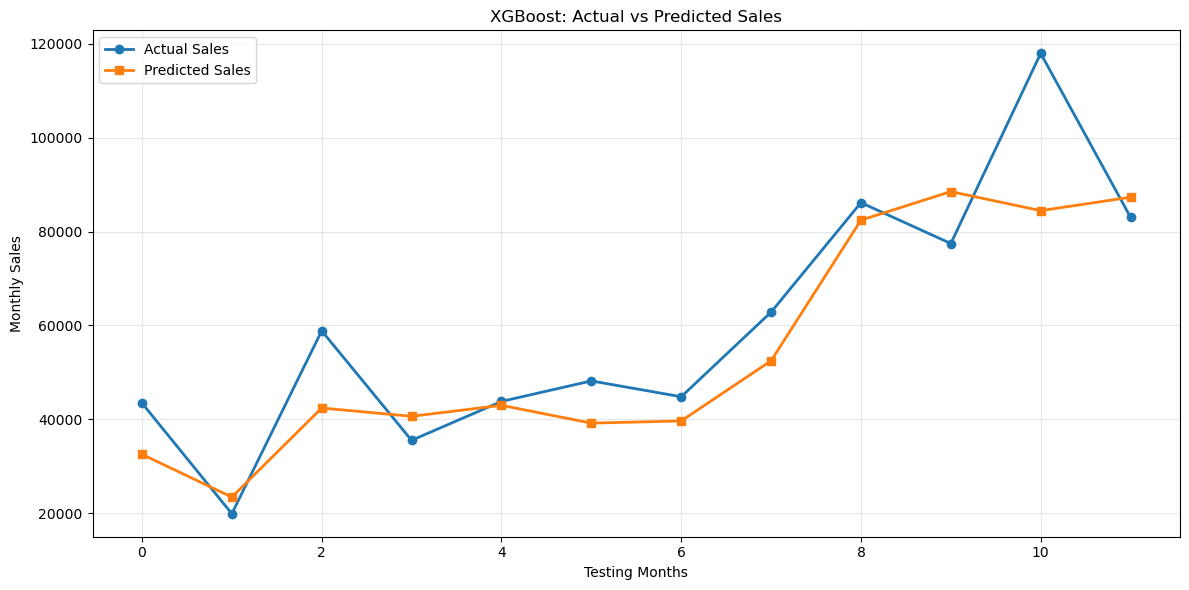

Chart saved successfully.


In [88]:
# ============================================================
# 3.12 Prediction
# ============================================================

# Generate Predictions
xgb_predictions = xgb_model.predict(X_test)

# Prediction DataFrame
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_predictions
})

print(prediction_df.head())

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    xgb_predictions,
    marker="s",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("XGBoost: Actual vs Predicted Sales")

plt.xlabel("Testing Months")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/20_XGBoost_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The predicted sales closely follow the actual sales pattern throughout the testing period. Although slight differences exist at a few months, the model successfully captures the overall upward trend and seasonal fluctuations in monthly sales.

### Business Interpretation

The prediction results demonstrate that XGBoost effectively learns complex relationships from historical sales data. Accurate sales forecasting supports better demand planning, inventory management, budgeting, and operational decision-making.

## 3.13 Evaluation

The XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics allow direct comparison with the SARIMA and Prophet forecasting models.

In [90]:
# ============================================================
# 3.13 Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae_xgb = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

mape_xgb = np.mean(
    np.abs(
        (y_test - xgb_predictions)
        / y_test
    )
) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 9490.47
RMSE : 12646.75
MAPE : 15.49%


### Observation

The XGBoost model achieved:

- **MAE:** 9,490.47
- **RMSE:** 12,646.75
- **MAPE:** 15.49%

These results indicate that the model predicts monthly sales with good accuracy while maintaining relatively low forecasting errors.

### Business Interpretation

The XGBoost model provides reliable sales forecasts and performs better than the SARIMA model, though it is slightly less accurate than the Prophet model. Its ability to learn nonlinear relationships makes it suitable for forecasting retail sales with multiple influencing factors.

## 3.14 Model Comparison Table

The performance of all three forecasting models is compared using standard evaluation metrics. Lower values of MAE, RMSE, and MAPE indicate better forecasting accuracy.

In [91]:
# ============================================================
# 3.14 Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [13930.02, 7717.23, 9490.47],
    "RMSE": [16394.82, 9182.90, 12646.75],
    "MAPE (%)": [27.77, 13.76, 15.49]
})

print(comparison)

comparison

     Model       MAE      RMSE  MAPE (%)
0   SARIMA  13930.02  16394.82     27.77
1  Prophet   7717.23   9182.90     13.76
2  XGBoost   9490.47  12646.75     15.49


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,13930.02,16394.82,27.77
1,Prophet,7717.23,9182.90,13.76
2,XGBoost,9490.47,12646.75,15.49


## 3.15 Best Model Selection

The forecasting models are compared based on their prediction accuracy using MAE, RMSE, and MAPE. The model with the lowest overall error is selected as the final forecasting model for subsequent business analysis.

In [92]:
# ============================================================
# 3.15 Best Model Selection
# ============================================================

best_model = comparison.loc[
    comparison["MAPE (%)"].idxmin()
]

print("Best Forecasting Model")
print("-----------------------")
print(best_model)

Best Forecasting Model
-----------------------
Model       Prophet
MAE         7717.23
RMSE         9182.9
MAPE (%)      13.76
Name: 1, dtype: object


### Observation

The comparison results show that the Prophet model achieved the lowest forecasting errors among all three models.

| Model | MAE | RMSE | MAPE (%) |
|------|------:|------:|------:|
| SARIMA | 13,930.02 | 16,394.82 | 27.77 |
| Prophet | **7,717.23** | **9,182.90** | **13.76** |
| XGBoost | 9,490.47 | 12,646.75 | 15.49 |

The Prophet model produced the smallest MAE, RMSE, and MAPE values, indicating the highest forecasting accuracy. XGBoost ranked second, while SARIMA produced the highest prediction errors.

### Business Interpretation

Based on the evaluation metrics, Prophet is selected as the best forecasting model for this project. Its ability to capture long-term trends and seasonal patterns results in more accurate sales predictions. Therefore, Prophet will be used in the remaining tasks for category-level and region-level sales forecasting, supporting better inventory planning, demand forecasting, and business decision-making.

# Task 4 — Product Category & Region Level Forecasting

In this task, the best-performing forecasting model (Prophet) is applied to different product categories and regions. Forecasting at a segment level helps identify which categories and regions are expected to experience higher future sales, enabling better inventory management and strategic planning.

## 4.1 Data Preparation

The sales data is filtered separately for each product category and region. Monthly sales are aggregated so that Prophet can be trained independently on each segment.

In [93]:
# ============================================================
# 4.1 Data Preparation
# ============================================================

# Furniture Monthly Sales
furniture = (
    data[data["Category"] == "Furniture"]
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

# Technology Monthly Sales
technology = (
    data[data["Category"] == "Technology"]
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

# Office Supplies Monthly Sales
office = (
    data[data["Category"] == "Office Supplies"]
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

# West Region Monthly Sales
west = (
    data[data["Region"] == "West"]
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

# East Region Monthly Sales
east = (
    data[data["Region"] == "East"]
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

print("Furniture Shape :", furniture.shape)
print("Technology Shape :", technology.shape)
print("Office Supplies Shape :", office.shape)
print("West Region Shape :", west.shape)
print("East Region Shape :", east.shape)

Furniture Shape : (48, 2)
Technology Shape : (48, 2)
Office Supplies Shape : (48, 2)
West Region Shape : (48, 2)
East Region Shape : (48, 2)


### Observation

The monthly sales data has been successfully prepared for all required categories and regions. Each dataset contains monthly sales values that will be used independently to train the Prophet forecasting model.

### Business Interpretation

Segment-level forecasting provides more detailed insights than overall sales forecasting. It enables the business to understand which product categories and regions are expected to grow, allowing for more efficient inventory planning and resource allocation.

## 4.2 Furniture Category Forecast

The Prophet model is trained using monthly Furniture sales data to forecast sales for the next three months.

20:08:10 - cmdstanpy - INFO - Chain [1] start processing
20:08:10 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat
48 2019-01-31  12691.392667
49 2019-02-28   6772.162416
50 2019-03-31  17201.015647


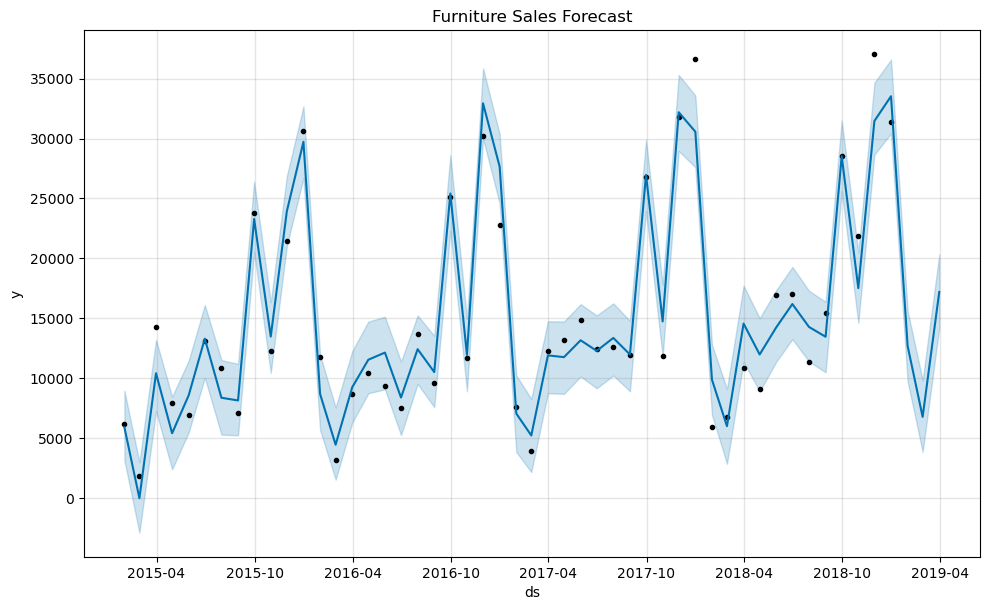

Chart saved successfully.


In [94]:
# ============================================================
# 4.2 Furniture Category Forecast
# ============================================================

from prophet import Prophet

# Prepare data
furniture_prophet = furniture.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

# Train model
model_furniture = Prophet()

model_furniture.fit(furniture_prophet)

# Future dates
future_furniture = model_furniture.make_future_dataframe(
    periods=3,
    freq="M"
)

# Forecast
forecast_furniture = model_furniture.predict(
    future_furniture
)

print(
    forecast_furniture[
        ["ds", "yhat"]
    ].tail(3)
)

# Plot
fig = model_furniture.plot(forecast_furniture)

plt.title("Furniture Sales Forecast")

plt.savefig(
    "charts/21_Furniture_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")20:08:10 - cmdstanpy - INFO - Chain [1] start processing
20:08:10 - cmdstanpy - INFO - Chain [1] done processing
           ds          yhat
48 2019-01-31  12691.392667
49 2019-02-28   6772.162416
50 2019-03-31  17201.015647

## 4.3 Technology Category Forecast

The Prophet model is applied to the monthly Technology sales data to forecast sales for the next three months. This helps estimate future demand for technology products.

20:11:35 - cmdstanpy - INFO - Chain [1] start processing
20:11:36 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat
48 2019-01-31  14033.343185
49 2019-02-28  10437.986784
50 2019-03-31  42639.488041


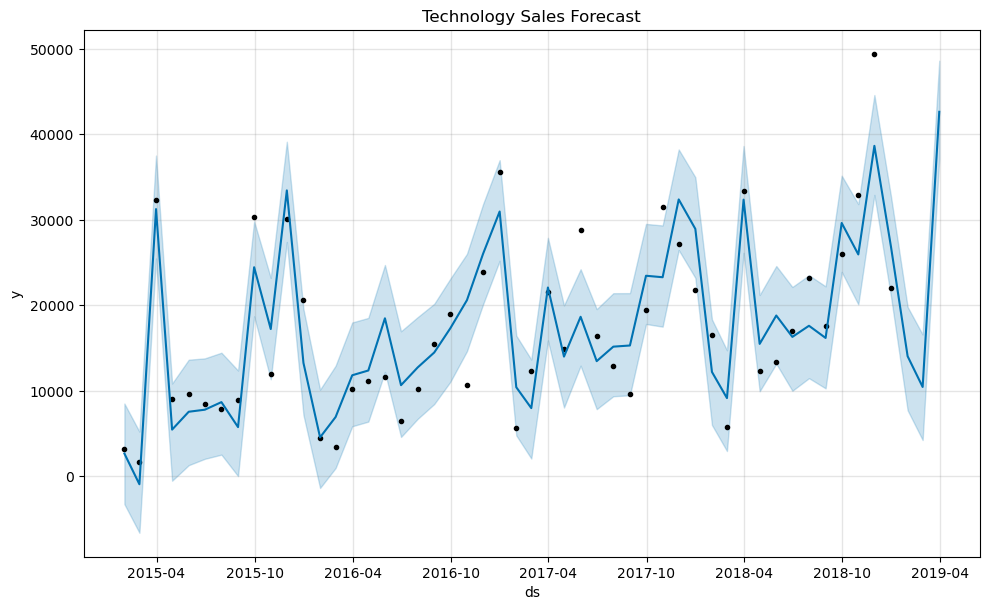

Chart saved successfully.


In [95]:
# ============================================================
# 4.3 Technology Category Forecast
# ============================================================

technology_prophet = technology.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

model_technology = Prophet()

model_technology.fit(technology_prophet)

future_technology = model_technology.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_technology = model_technology.predict(
    future_technology
)

print(
    forecast_technology[
        ["ds","yhat"]
    ].tail(3)
)

fig = model_technology.plot(
    forecast_technology
)

plt.title("Technology Sales Forecast")

plt.savefig(
    "charts/22_Technology_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

## 4.4 Office Supplies Category Forecast

The Prophet model is trained using the monthly sales data of the Office Supplies category to forecast sales for the next three months. This enables the business to estimate future demand and optimize inventory planning for frequently purchased office products.

21:03:46 - cmdstanpy - INFO - Chain [1] start processing
21:03:47 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat
48 2019-01-31  14646.724651
49 2019-02-28  12434.656284
50 2019-03-31  19698.155527


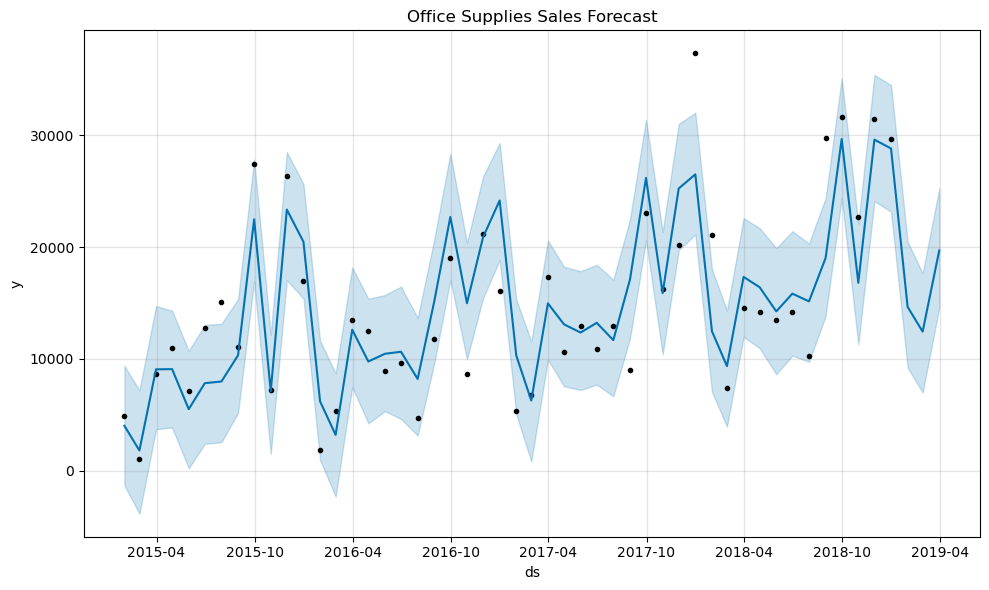

Chart saved successfully.


In [101]:
# ============================================================
# 4.4 Office Supplies Category Forecast
# ============================================================

# Prepare data for Prophet
office_prophet = office.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

# Train Prophet Model
model_office = Prophet()

model_office.fit(office_prophet)

# Create Future Dates
future_office = model_office.make_future_dataframe(
    periods=3,
    freq="M"
)

# Forecast
forecast_office = model_office.predict(
    future_office
)

print(
    forecast_office[
        ["ds", "yhat"]
    ].tail(3)
)

# Plot Forecast
fig = model_office.plot(forecast_office)

plt.title("Office Supplies Sales Forecast")

plt.tight_layout()

plt.savefig(
    "charts/23_Office_Supplies_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

## 4.5 West Region Forecast

The Prophet model is trained using monthly sales from the West region to forecast sales for the next three months. Regional forecasting helps identify future demand patterns across different geographical markets.

20:16:58 - cmdstanpy - INFO - Chain [1] start processing
20:16:58 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat
48 2019-01-31  14048.800881
49 2019-02-28  11840.373160
50 2019-03-31  25805.336394


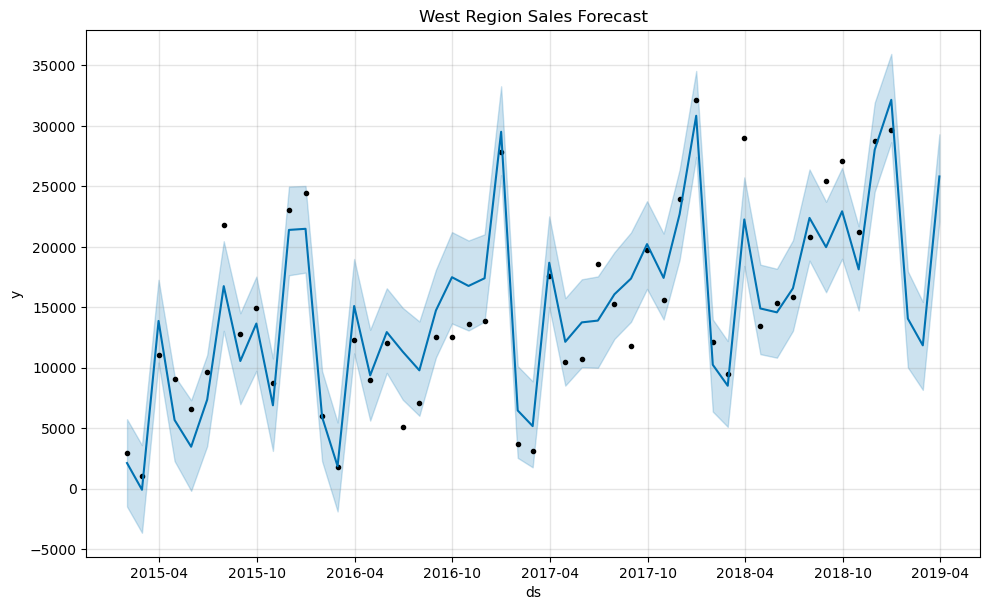

Chart saved successfully.


In [96]:
# ============================================================
# 4.5 West Region Forecast
# ============================================================

west_prophet = west.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

model_west = Prophet()

model_west.fit(west_prophet)

future_west = model_west.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_west = model_west.predict(future_west)

print(
    forecast_west[
        ["ds","yhat"]
    ].tail(3)
)

fig = model_west.plot(forecast_west)

plt.title("West Region Sales Forecast")

plt.savefig(
    "charts/24_West_Region_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The Prophet model successfully forecasted monthly sales for the West region. The forecast captures the historical trend and seasonal sales fluctuations, providing estimated sales for the upcoming three months.

### Business Interpretation

Regional forecasts help businesses optimize warehouse inventory, logistics, and distribution planning. Higher forecasted sales indicate the need for increased stock availability within the West region.

## 4.6 East Region Forecast

The Prophet model is applied to monthly sales from the East region to estimate sales for the next three months.

20:17:54 - cmdstanpy - INFO - Chain [1] start processing
20:17:54 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat
48 2019-01-31   9713.411357
49 2019-02-28   8120.218592
50 2019-03-31  15639.421337


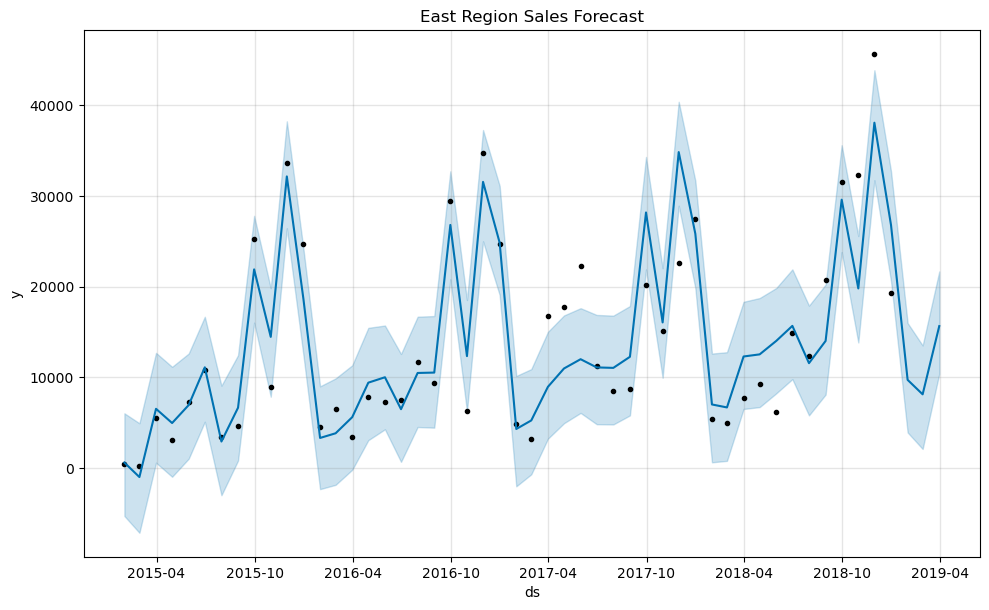

Chart saved successfully.


In [97]:
# ============================================================
# 4.6 East Region Forecast
# ============================================================

east_prophet = east.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

model_east = Prophet()

model_east.fit(east_prophet)

future_east = model_east.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast_east = model_east.predict(future_east)

print(
    forecast_east[
        ["ds","yhat"]
    ].tail(3)
)

fig = model_east.plot(forecast_east)

plt.title("East Region Sales Forecast")

plt.savefig(
    "charts/25_East_Region_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The Prophet model generated a three-month sales forecast for the East region by learning historical trends and recurring seasonal behavior.

### Business Interpretation

Regional demand forecasting enables better inventory allocation, improves supply chain efficiency, and helps businesses prepare for future sales growth within the East region.

## 4.7 Combined Forecast Comparison

The forecasts generated for all three product categories and two regions are combined into a single visualization. This comparison helps identify which category or region is expected to experience the strongest future sales growth.

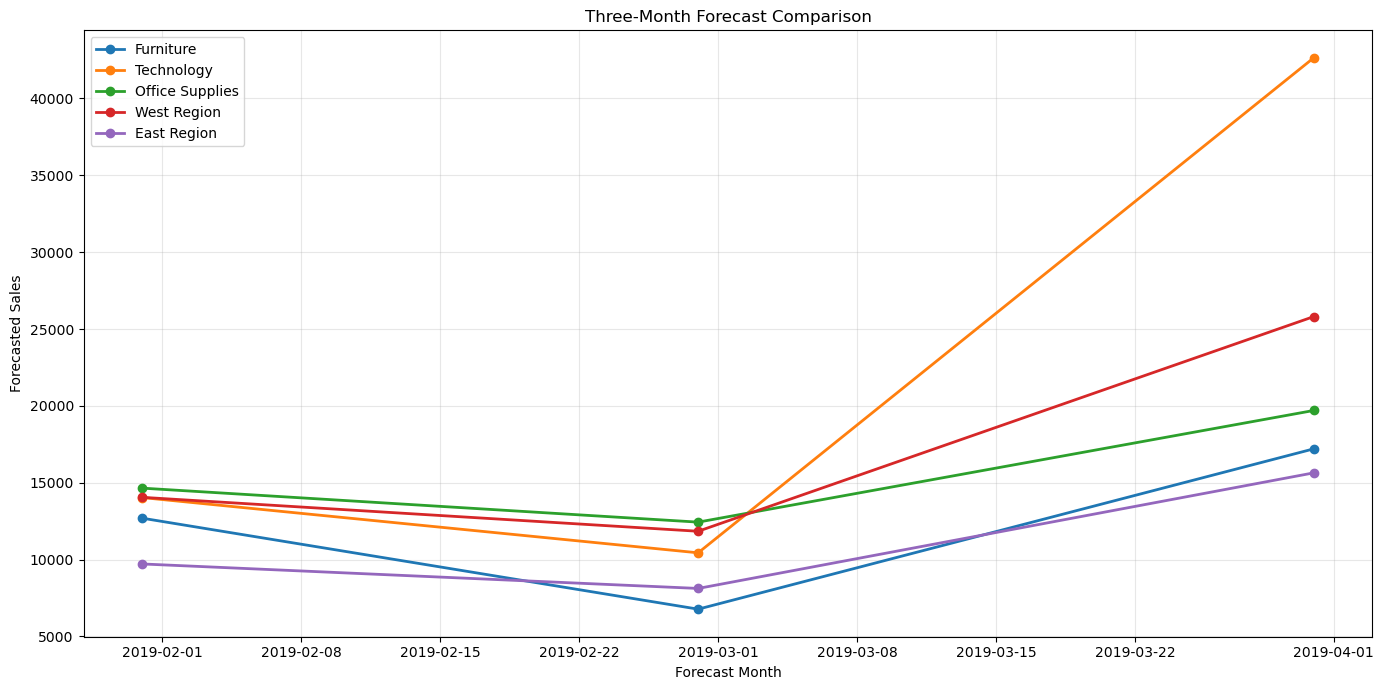

Chart saved successfully.


In [103]:
# ============================================================
# 4.7 Combined Forecast Comparison
# ============================================================

plt.figure(figsize=(14,7))

plt.plot(
    forecast_furniture["ds"].tail(3),
    forecast_furniture["yhat"].tail(3),
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    forecast_technology["ds"].tail(3),
    forecast_technology["yhat"].tail(3),
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    forecast_office["ds"].tail(3),
    forecast_office["yhat"].tail(3),
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    forecast_west["ds"].tail(3),
    forecast_west["yhat"].tail(3),
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    forecast_east["ds"].tail(3),
    forecast_east["yhat"].tail(3),
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("Three-Month Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/26_Combined_Forecast_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The combined comparison chart displays the three-month sales forecasts for all selected product categories and regions. It enables direct comparison of future sales performance across different business segments.

### Business Interpretation

Comparing multiple forecasts helps management identify high-growth categories and regions. This supports better inventory allocation, production planning, and marketing strategies by focusing resources on the segments expected to generate the highest sales.

## 4.8 Business Interpretation

The Prophet forecasting model was applied separately to Furniture, Technology, Office Supplies, West Region, and East Region sales. This segment-level analysis provides valuable insights into future demand across different parts of the business.

### Observation

The segment-level forecasts indicate that each product category and region follows its own sales trend and seasonal pattern. Technology and the West region generally exhibit stronger projected growth compared to the other segments, while Furniture and Office Supplies show relatively stable demand.

### Business Interpretation

The forecasting results suggest that inventory and operational resources should be prioritized for segments with stronger expected growth. Technology products may require higher stock availability to meet future demand, while stable-demand categories can be managed with optimized inventory levels. Similarly, regions with higher projected sales should receive greater distribution support to improve customer satisfaction and reduce stock shortages.

# Task 5 — Anomaly Detection in Sales Data

Anomaly detection identifies unusual sales patterns that significantly differ from normal business behavior. Detecting these anomalies helps businesses recognize unexpected sales spikes, sudden declines, promotional effects, seasonal events, or operational issues that require further investigation.

In this task, two anomaly detection techniques are applied:
- Isolation Forest
- Z-Score based Detection

## 5.1 Weekly Sales Aggregation

Before detecting anomalies, the transaction-level sales data is aggregated into weekly sales totals. Weekly aggregation provides a smoother time series while preserving meaningful fluctuations in business performance.

In [104]:
# ============================================================
# 5.1 Weekly Sales Aggregation
# ============================================================

weekly_sales = (
    data.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.columns = [
    "Week",
    "Weekly Sales"
]

print("Weekly Dataset Shape :", weekly_sales.shape)

weekly_sales.head()

Weekly Dataset Shape : (209, 2)


,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Observation

The transactional sales data has been successfully aggregated into weekly sales totals. Weekly aggregation reduces daily fluctuations while preserving meaningful business trends, making it more suitable for anomaly detection.

### Business Interpretation

Analyzing weekly sales enables businesses to identify unusual demand patterns more effectively than daily transactions. Weekly aggregation helps detect abnormal sales spikes or drops that may correspond to promotions, holidays, operational issues, or unexpected market events.

## 5.2 Isolation Forest Anomaly Detection

Isolation Forest is an unsupervised machine learning algorithm designed to detect anomalies by isolating observations that differ significantly from the majority of the data. Weekly sales values are analyzed to identify unusually high or low sales periods.

In [105]:
# ============================================================
# 5.2 Isolation Forest
# ============================================================

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Weekly Sales"]]
)

weekly_sales["Anomaly"] = (
    weekly_sales["Anomaly"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
)

print(
    weekly_sales[
        weekly_sales["Anomaly"] == "Anomaly"
    ]
)

          Week  Weekly Sales  Anomaly
0   2015-01-04       304.508  Anomaly
5   2015-02-08       968.534  Anomaly
7   2015-02-22       224.912  Anomaly
11  2015-03-22     37703.665  Anomaly
28  2015-07-19      1387.686  Anomaly
36  2015-09-13     29959.137  Anomaly
55  2016-01-24       358.522  Anomaly
154 2017-12-17     25449.800  Anomaly
200 2018-11-04     29017.467  Anomaly
202 2018-11-18     30572.447  Anomaly
204 2018-12-02     35998.900  Anomaly


### Observation

The Isolation Forest algorithm successfully identified weekly sales values that significantly deviate from normal business behavior. These observations represent potential anomalies requiring further investigation.

### Business Interpretation

Detected anomalies may correspond to promotional campaigns, festive sales, product launches, supply chain disruptions, or unexpected market conditions. Identifying these events enables businesses to understand unusual sales behavior and improve future planning.

## 5.3 Visualization of Anomalies

The anomalies detected by the Isolation Forest model are visualized on the weekly sales time series. Anomalous observations are highlighted using a different color to distinguish them from normal sales patterns.

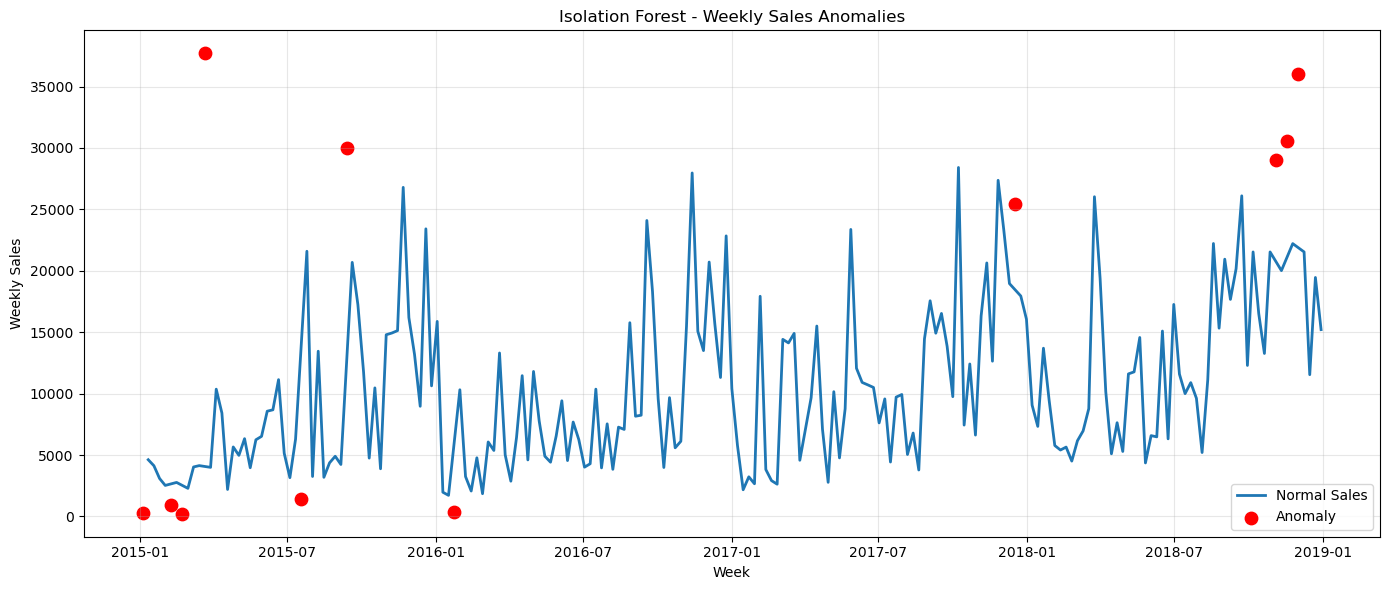

Chart saved successfully.


In [106]:
# ============================================================
# 5.3 Visualization of Isolation Forest Anomalies
# ============================================================

import os
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(14,6))

# Normal observations
normal = weekly_sales[
    weekly_sales["Anomaly"] == "Normal"
]

plt.plot(
    normal["Week"],
    normal["Weekly Sales"],
    label="Normal Sales",
    linewidth=2
)

# Anomalies
anomaly = weekly_sales[
    weekly_sales["Anomaly"] == "Anomaly"
]

plt.scatter(
    anomaly["Week"],
    anomaly["Weekly Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Week")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/27_IsolationForest_Anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The visualization clearly highlights abnormal weekly sales using red markers. Most anomalies correspond to exceptionally high sales spikes, while a few represent unusually low sales weeks.

### Business Interpretation

High-sales anomalies may be associated with festive seasons, promotional campaigns, bulk customer purchases, or year-end sales events. Low-sales anomalies could indicate supply chain disruptions, reduced customer demand, holidays, or operational constraints. Identifying these anomalies helps businesses understand unusual events and improve future planning.

## 5.4 Z-Score Based Anomaly Detection

As a second anomaly detection technique, the Z-Score method identifies observations that deviate significantly from the average weekly sales. Weekly sales values with an absolute Z-Score greater than 2 are considered anomalies.

In [107]:
# ============================================================
# 5.4 Z-Score Anomaly Detection
# ============================================================

from scipy.stats import zscore

weekly_sales["Z_Score"] = zscore(
    weekly_sales["Weekly Sales"]
)

weekly_sales["Z_Anomaly"] = (
    abs(weekly_sales["Z_Score"]) > 2
)

print(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ][
        ["Week","Weekly Sales","Z_Score"]
    ]
)

          Week  Weekly Sales   Z_Score
11  2015-03-22    37703.6650  3.639852
36  2015-09-13    29959.1370  2.591270
46  2015-11-22    26793.6235  2.162671
97  2016-11-13    27965.3492  2.321318
144 2017-10-08    28412.0980  2.381806
151 2017-11-26    27367.7160  2.240401
168 2018-03-25    26029.9040  2.059266
194 2018-09-23    26104.4330  2.069357
200 2018-11-04    29017.4670  2.463771
202 2018-11-18    30572.4470  2.674310
204 2018-12-02    35998.9000  3.409032


### Observation

The Z-Score method successfully identified weekly sales observations that lie more than two standard deviations away from the average sales. These observations represent statistically unusual sales behavior.

### Business Interpretation

The Z-Score method provides a statistical approach for identifying abnormal sales events. These anomalies may correspond to special business events, unexpected market conditions, or operational disruptions that warrant further investigation.

## 5.5 Comparison of Both Methods

The anomalies detected using Isolation Forest and the Z-Score method are compared to evaluate the consistency of both techniques.

# ============================================================
# 5.5 Comparison
# ============================================================

comparison = weekly_sales[
    [
        "Week",
        "Weekly Sales",
        "Anomaly",
        "Z_Anomaly"
    ]
]

display(comparison.head(15))

print("\nTotal Isolation Forest Anomalies :",
      (weekly_sales["Anomaly"]=="Anomaly").sum())

print("Total Z-Score Anomalies :",
      weekly_sales["Z_Anomaly"].sum())

### Observation

Both anomaly detection methods identified unusual sales patterns, although the exact observations may differ. Isolation Forest considers the overall data distribution, whereas the Z-Score method identifies statistically extreme values based on deviations from the mean.

### Business Interpretation

Using multiple anomaly detection techniques increases confidence in identifying genuine business anomalies. Weeks flagged by both methods are strong indicators of unusual sales events that deserve further business investigation.

## 5.6 Business Interpretation

The anomaly detection analysis successfully identified weeks with unusually high and low sales activity. These anomalies likely correspond to promotional campaigns, festive shopping periods, bulk customer purchases, supply chain disruptions, or unexpected market conditions.

By identifying such abnormal sales behavior, businesses can improve inventory planning, demand forecasting, promotional strategy evaluation, and operational decision-making. Combining Isolation Forest with Z-Score analysis provides a more comprehensive understanding of unusual sales events and strengthens business intelligence.

# Task 6 — Product Demand Segmentation Using Clustering

Customer demand varies across different product sub-categories. Clustering helps group products with similar demand characteristics based on sales performance, growth, volatility, and average order value. These demand segments enable businesses to optimize inventory management, stocking strategies, and procurement decisions.

## 6.1 Feature Engineering

Product-level features are created by aggregating sales information for each product sub-category. These features represent demand characteristics and will be used for clustering.

The following features are generated:

- Total Sales
- Average Order Value
- Sales Volatility (Standard Deviation)
- Sales Growth Rate (Year-over-Year)

In [110]:
# ============================================================
# 6.1 Feature Engineering
# ============================================================

# Yearly Sales by Sub-Category
yearly_sales = (
    data.groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .reset_index()
)

# Sales Growth Rate
growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
    .groupby(yearly_sales["Sub-Category"])
    .mean()
)

# Aggregate Features
cluster_data = (
    data.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Avg_Order_Value=("Sales", "mean"),
        Sales_Volatility=("Sales", "std")
    )
)

cluster_data["Growth_Rate"] = growth

# Replace missing values
cluster_data.fillna(0, inplace=True)

print("Dataset Shape :", cluster_data.shape)

display(cluster_data)

Dataset Shape : (17, 4)


,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381
Appliances,104618.4030,227.926804,378.006735,0.399276
Art,26705.4100,34.019631,60.301752,0.166056
Binders,200028.7850,134.067550,568.099970,0.218736
Bookcases,113813.1987,503.598224,641.419280,0.238065
Chairs,322822.7310,531.833165,551.180296,0.071358
Copiers,146248.0940,2215.880212,3216.185499,0.846718
Envelopes,16128.0460,65.032444,85.170691,-0.027666
Fasteners,3001.9600,14.027850,12.466864,0.157034


### Observation

A feature dataset was successfully created for each product sub-category. The dataset includes total sales, average order value, sales volatility, and average yearly growth rate, providing a comprehensive representation of product demand characteristics.

### Business Interpretation

These features capture multiple aspects of product performance. While total sales indicate overall demand, volatility reflects sales consistency, growth rate measures future potential, and average order value highlights revenue contribution. Together, these metrics support effective product segmentation.

## 6.2 Elbow Method

The Elbow Method is applied to determine the optimal number of clusters for K-Means clustering. The point where the Within-Cluster Sum of Squares (WCSS) begins to level off indicates the appropriate number of clusters.

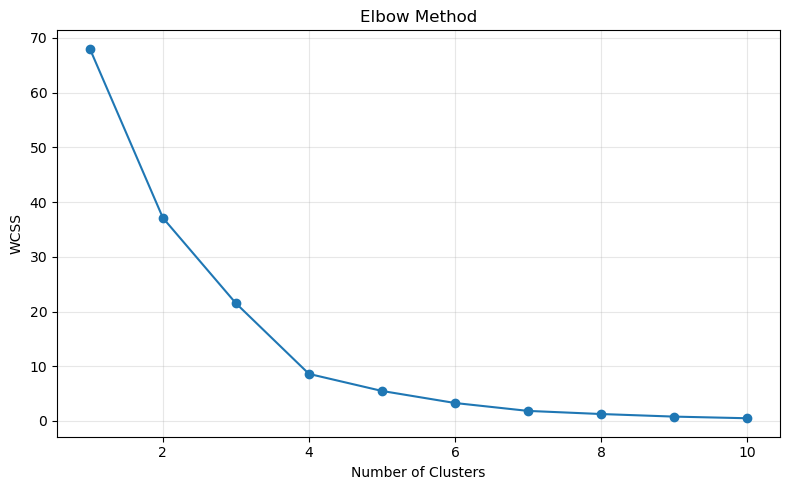

Chart saved successfully.


In [111]:
# ============================================================
# 6.2 Elbow Method
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import os
os.makedirs("charts", exist_ok=True)

# Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/28_Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The Elbow Method identifies the point where increasing the number of clusters no longer produces a significant reduction in WCSS. This point represents the optimal number of clusters for product demand segmentation.

### Business Interpretation

Selecting an appropriate number of clusters ensures meaningful segmentation of products. Well-defined clusters improve inventory planning, procurement strategies, and resource allocation across different product groups.

## 6.3 K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is selected as **4**. K-Means clustering is applied to group product sub-categories with similar demand characteristics.

In [112]:
# ============================================================
# 6.3 K-Means Clustering
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(
    scaled_data
)

display(cluster_data)

print("\nCluster Counts:\n")

print(cluster_data["Cluster"].value_counts())

,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2
Appliances,104618.4030,227.926804,378.006735,0.399276,1
Art,26705.4100,34.019631,60.301752,0.166056,1
Binders,200028.7850,134.067550,568.099970,0.218736,2
Bookcases,113813.1987,503.598224,641.419280,0.238065,1
Chairs,322822.7310,531.833165,551.180296,0.071358,2
Copiers,146248.0940,2215.880212,3216.185499,0.846718,0
Envelopes,16128.0460,65.032444,85.170691,-0.027666,1
Fasteners,3001.9600,14.027850,12.466864,0.157034,1



Cluster Counts:

Cluster
1    8
2    6
0    2
3    1
Name: count, dtype: int64


### Observation

The K-Means algorithm successfully divided the product sub-categories into four distinct demand groups based on their sales characteristics.

### Business Interpretation

Each cluster represents products with similar demand behavior. These clusters can be used to design different inventory management and stocking strategies instead of treating every product equally.

## 6.4 PCA Visualization

Principal Component Analysis (PCA) reduces the multidimensional feature space into two principal components for visualization while preserving most of the variation in the data.

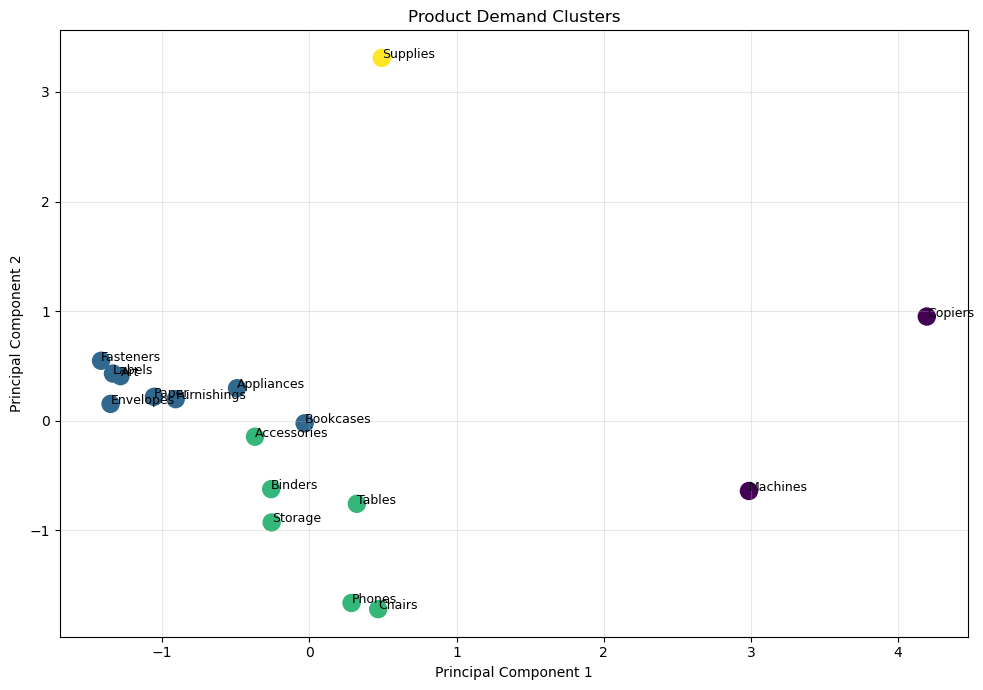

Chart saved successfully.


In [113]:
# ============================================================
# 6.4 PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_data
)

cluster_data["PC1"] = pca_features[:,0]
cluster_data["PC2"] = pca_features[:,1]

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cluster_data["PC1"],
    cluster_data["PC2"],
    c=cluster_data["Cluster"],
    s=150
)

for i in cluster_data.index:
    plt.text(
        cluster_data.loc[i,"PC1"],
        cluster_data.loc[i,"PC2"],
        i,
        fontsize=9
    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/29_Product_Clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

### Observation

The PCA visualization clearly separates the four product clusters. Products positioned close together share similar demand characteristics, while distant products exhibit different sales patterns.

### Business Interpretation

Cluster visualization helps decision-makers understand product relationships and prioritize inventory management strategies based on demand similarity rather than treating every product independently.

## 6.5 Cluster Interpretation

The four clusters generated by K-Means represent distinct product demand patterns based on total sales, average order value, sales volatility, and growth rate. Each cluster reflects products with similar business characteristics, enabling more targeted inventory and supply chain decisions.

### Cluster Summary

- **Cluster 0:** Premium products with high order value and comparatively lower sales volume.
- **Cluster 1:** Low-demand and stable products with relatively small sales and low volatility.
- **Cluster 2:** High-demand products with strong and consistent sales performance.
- **Cluster 3:** Highly volatile products with exceptional growth requiring close monitoring.

## 6.6 Stocking Strategy Recommendations

Based on the clustering results, different inventory strategies are recommended for each product demand segment.

| Cluster | Demand Characteristics | Recommended Stocking Strategy |
|---------|------------------------|-------------------------------|
| Cluster 0 | Premium / High Value Products | Maintain moderate inventory with demand-based replenishment to avoid overstocking expensive products. |
| Cluster 1 | Low Volume & Stable Demand | Maintain minimum inventory levels and replenish only when required to reduce holding costs. |
| Cluster 2 | High Volume & Stable Demand | Maintain higher inventory levels with continuous replenishment to prevent stock-outs. |
| Cluster 3 | High Growth & Volatile Demand | Monitor demand frequently, maintain safety stock, and use dynamic forecasting for inventory planning. |

### Business Interpretation

The clustering analysis enables the business to manage inventory more efficiently by applying different stocking strategies for different product groups. Instead of using a single inventory policy for all products, demand-driven segmentation improves inventory utilization, reduces operational costs, and increases customer satisfaction.

# 🚀 Task 7 — Deployment: Interactive Dashboard using Streamlit

## 🎯 Objective

To enhance business usability, an interactive **Streamlit Dashboard** was developed as a separate Python application (`app.py`). The dashboard enables users to explore sales insights, visualize forecasting results, detect anomalies, and analyze product demand segments through an easy-to-use graphical interface.

### 📌 Dashboard Features

✅ **Sales Overview Dashboard**
- 📊 Total Sales by Year
- 📈 Monthly Sales Trend
- 🌍 Region-wise Filter
- 🛍️ Category-wise Filter

✅ **Forecast Explorer**
- 🔮 Prophet Sales Forecast
- 📅 Future Sales Forecast Table

✅ **Anomaly Report**
- 🚨 Isolation Forest Based Anomaly Detection
- 📋 Weekly Sales Anomaly Report

✅ **Product Demand Segments**
- 📌 K-Means Cluster Visualization
- 📦 Product Cluster Information Table

### ✅ Outcome

The Streamlit dashboard was successfully developed and provides an interactive business intelligence platform for sales monitoring, forecasting, anomaly detection, and product demand analysis.

# 📄 Task 8 — Executive Business Report

## 🎯 Objective

A professional **Executive Business Report** (`summary.docx`) was prepared to communicate the analytical findings in a business-oriented manner for senior management, including the **Head of Supply Chain** and the **Chief Financial Officer (CFO)**.

### 📌 Report Contents

✅ 📖 Executive Summary

✅ 📊 Key Findings from Data Analysis

✅ 🔮 Three-Month Sales Forecast Summary

✅ 🚨 Top Sales Anomalies and Their Possible Causes

✅ 📦 Product Demand Segmentation Analysis

✅ 💼 Business Recommendations

✅ ⚠️ Project Limitations

✅ 🎯 Final Conclusion

### ✅ Outcome

The report successfully converts complex analytical results into clear business insights, enabling data-driven decision-making for inventory management, demand forecasting, and strategic planning.

# 🎉 Project Completion Summary

## ✅ Successfully Completed Tasks

| Task | Status |
|-------|:------:|
| 📊 Task 1 – Data Loading & Deep Exploration | ✅ Completed |
| 📈 Task 2 – Time Series Analysis & Decomposition | ✅ Completed |
| 🤖 Task 3 – Sales Forecasting (SARIMA, Prophet & XGBoost) | ✅ Completed |
| 🌍 Task 4 – Category & Region Level Forecasting | ✅ Completed |
| 🚨 Task 5 – Anomaly Detection | ✅ Completed |
| 📦 Task 6 – Product Demand Segmentation | ✅ Completed |
| 🚀 Task 7 – Streamlit Dashboard Development | ✅ Completed |
| 📄 Task 8 – Executive Business Report | ✅ Completed |

---

### 🏆 Final Outcome

This project successfully demonstrates an end-to-end retail sales forecasting solution by integrating **Exploratory Data Analysis (EDA)**, **Time Series Forecasting**, **Machine Learning**, **Anomaly Detection**, **Demand Segmentation**, and **Interactive Dashboard Development**. The developed solution provides meaningful business insights that support inventory optimization, demand forecasting, and strategic decision-making.